In [12]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
rentals = pd.read_csv("FloridaBikeRentals - FloridaBikeRentals.csv")
# Clean up column names by removing Chinese characters
rentals.columns = rentals.columns.str.replace('蚓', 'C', regex=False)


In [17]:
rentals

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


In [4]:
rentals.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(蚓)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(蚓)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-null   float64
 9   Rainfall(mm)              8760 non-null   float64
 10  Snowfall (cm)             8760 non-null   float64
 11  Seasons                   8760 non-null   object 
 12  Holiday                   8760 non-null   object 
 13  Functioning Day           8760 non-null   object 
dtypes: float

In [5]:
rentals.describe()

,Rented Bike Count,Hour,Temperature(蚓),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(蚓),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [7]:
rentals.isnull().sum()

Date                        0
Rented Bike Count           0
Hour                        0
Temperature(蚓)              0
Humidity(%)                 0
Wind speed (m/s)            0
Visibility (10m)            0
Dew point temperature(蚓)    0
Solar Radiation (MJ/m2)     0
Rainfall(mm)                0
Snowfall (cm)               0
Seasons                     0
Holiday                     0
Functioning Day             0
dtype: int64

## Create a date time column

In [18]:
# Method 1: Using pd.to_datetime() with format specification
rentals['DateTime'] = pd.to_datetime(rentals['Date'] + ' ' + rentals['Hour'].astype(str) + ':00:00',
                                    format='%d/%m/%Y %H:%M:%S')

# Let's check the result
print("Original Date and Hour:")
print(rentals[['Date', 'Hour']].head())
print("\nNew DateTime column:")
print(rentals['DateTime'].head())
print(f"\nDataType of DateTime: {rentals['DateTime'].dtype}")


Original Date and Hour:
         Date  Hour
0  01/12/2017     0
1  01/12/2017     1
2  01/12/2017     2
3  01/12/2017     3
4  01/12/2017     4

New DateTime column:
0   2017-12-01 00:00:00
1   2017-12-01 01:00:00
2   2017-12-01 02:00:00
3   2017-12-01 03:00:00
4   2017-12-01 04:00:00
Name: DateTime, dtype: datetime64[ns]

DataType of DateTime: datetime64[ns]


In [19]:
# Verify the datetime creation
print("Date range:", rentals['DateTime'].min(), "to", rentals['DateTime'].max())
print("Total records:", len(rentals))
print("Unique dates:", rentals['DateTime'].dt.date.nunique())
print("Hours per day check:", len(rentals) / rentals['DateTime'].dt.date.nunique())

Date range: 2017-12-01 00:00:00 to 2018-11-30 23:00:00
Total records: 8760
Unique dates: 365
Hours per day check: 24.0


# Steps to take


## Project Overview
**Goal**: Build a model to predict hourly bike rental demand for stable supply management

## Implementation Plan

Based on the guidelines, here's what we need to accomplish:

### 1. **Data Loading & Preprocessing** ✅ (Partially Done)
- Load dataset ✅
- Check for null values ✅ (No missing values found)
- Convert Date column and extract temporal features

### 2. **Exploratory Data Analysis (EDA)**
- Correlation heatmap of features
- Distribution plot of Rented Bike Count
- Histograms of all numerical features
- Box plots of Rented Bike Count vs categorical features
- Seaborn catplots for specific feature relationships

### 3. **Feature Engineering**
- Encode categorical features using get_dummies
- Create additional temporal features from Date

### 4. **Model Building**
- Split data (80:20, random_state=1)
- Standard scaling
- Compare Linear, Lasso, and Ridge regression models

## Next Steps

Let's start implementing these tasks. You've already completed the initial data loading and null value checking.

**What would you like to work on first?**

1. **Date preprocessing and temporal feature extraction** - Convert the Date column and create day, month, day of week, weekend features
2. **Correlation analysis** - Create the heatmap to understand feature relationships
3. **Distribution analysis** - Plot the target variable distribution and numerical feature histograms
4. **Categorical analysis** - Box plots and catplots for categorical features

Or would you prefer to work through them sequentially? I can help you implement each step with the appropriate code and provide insights as we go.

Which approach would you like to take?

# create correlation heatmap of features

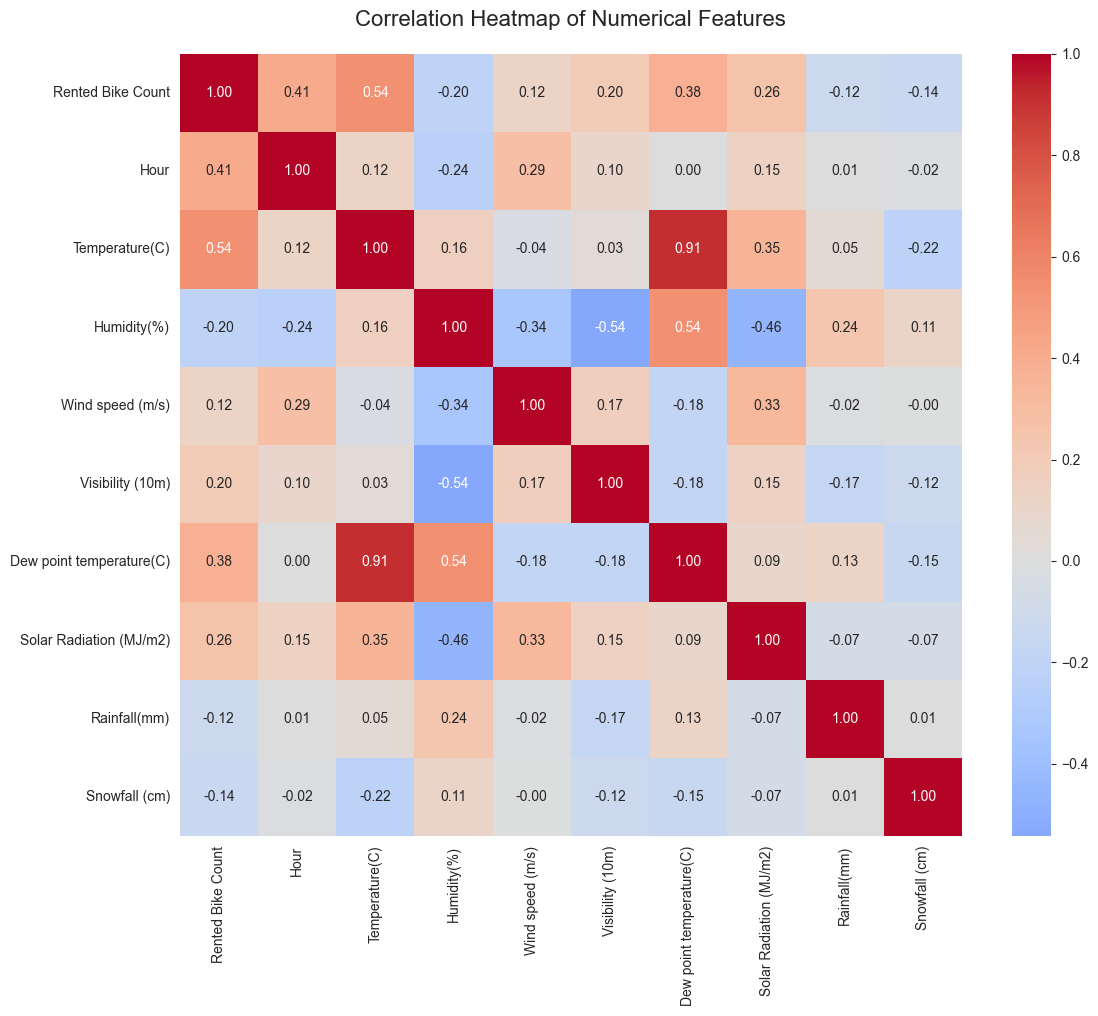

In [20]:
# First, let's create the correlation matrix for numerical features only
# Select only numerical columns
numerical_cols = rentals.select_dtypes(include=[np.number]).columns
correlation_matrix = rentals[numerical_cols].corr()

# Create a basic correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,           # Show correlation values
            cmap='coolwarm',      # Color scheme
            center=0,             # Center colormap at 0
            square=True,          # Make cells square
            fmt='.2f')            # Format to 2 decimal places
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## Correlation values

In [22]:
# Show the correlation matrix values
correlation_matrix = rentals.select_dtypes(include=[np.number]).corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

# Focus on correlations with the target variable
target_correlations = correlation_matrix['Rented Bike Count'].sort_values(key=abs, ascending=False)
print("\nCorrelations with Rented Bike Count (sorted by strength):")
print("=" * 50)
for feature, corr in target_correlations.items():
    print(f"{feature:30}: {corr:6.3f}")


Correlation Matrix:
                          Rented Bike Count   Hour  Temperature(C)  \
Rented Bike Count                     1.000  0.410           0.539   
Hour                                  0.410  1.000           0.124   
Temperature(C)                        0.539  0.124           1.000   
Humidity(%)                          -0.200 -0.242           0.159   
Wind speed (m/s)                      0.121  0.285          -0.036   
Visibility (10m)                      0.199  0.099           0.035   
Dew point temperature(C)              0.380  0.003           0.913   
Solar Radiation (MJ/m2)               0.262  0.145           0.354   
Rainfall(mm)                         -0.123  0.009           0.050   
Snowfall (cm)                        -0.142 -0.022          -0.218   

                          Humidity(%)  Wind speed (m/s)  Visibility (10m)  \
Rented Bike Count              -0.200             0.121             0.199   
Hour                           -0.242             0.285

## Key Insights for Your Model
Based on these correlations:
1. **Temperature is your strongest predictor** (0.539) - definitely include this
2. **Hour of day matters significantly** (0.410) - time-based patterns are important
3. **Weather conditions matter** - temperature, humidity, visibility, rainfall, and snowfall all show meaningful correlations
4. **Dew point temperature** is highly correlated with regular temperature (0.913), so you might want to consider removing one to avoid multicollinearity

The correlation analysis confirms that weather and temporal features will be crucial for your bike demand prediction model!


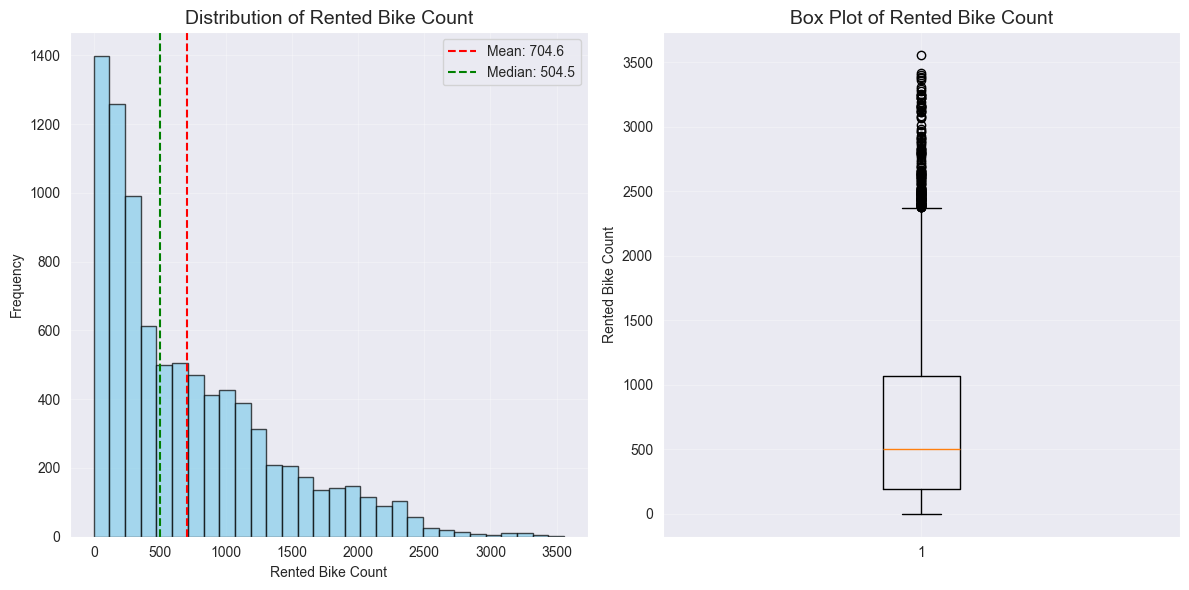

Distribution Statistics for Rented Bike Count:
Mean: 704.60
Median: 504.50
Standard Deviation: 645.00
Minimum: 0


In [23]:

# Distribution plot of Rented Bike Count
plt.figure(figsize=(12, 6))

# Create subplot with histogram and distribution curve
plt.subplot(1, 2, 1)
plt.hist(rentals['Rented Bike Count'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Rented Bike Count', fontsize=14)
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

# Add statistics text
mean_val = rentals['Rented Bike Count'].mean()
median_val = rentals['Rented Bike Count'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.1f}')
plt.legend()

# Box plot for additional insights
plt.subplot(1, 2, 2)
plt.boxplot(rentals['Rented Bike Count'])
plt.title('Box Plot of Rented Bike Count', fontsize=14)
plt.ylabel('Rented Bike Count')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Distribution Statistics for Rented Bike Count:")
print("=" * 45)
print(f"Mean: {rentals['Rented Bike Count'].mean():.2f}")
print(f"Median: {rentals['Rented Bike Count'].median():.2f}")
print(f"Standard Deviation: {rentals['Rented Bike Count'].std():.2f}")
print(f"Minimum: {rentals['Rented Bike Count'].min()}")


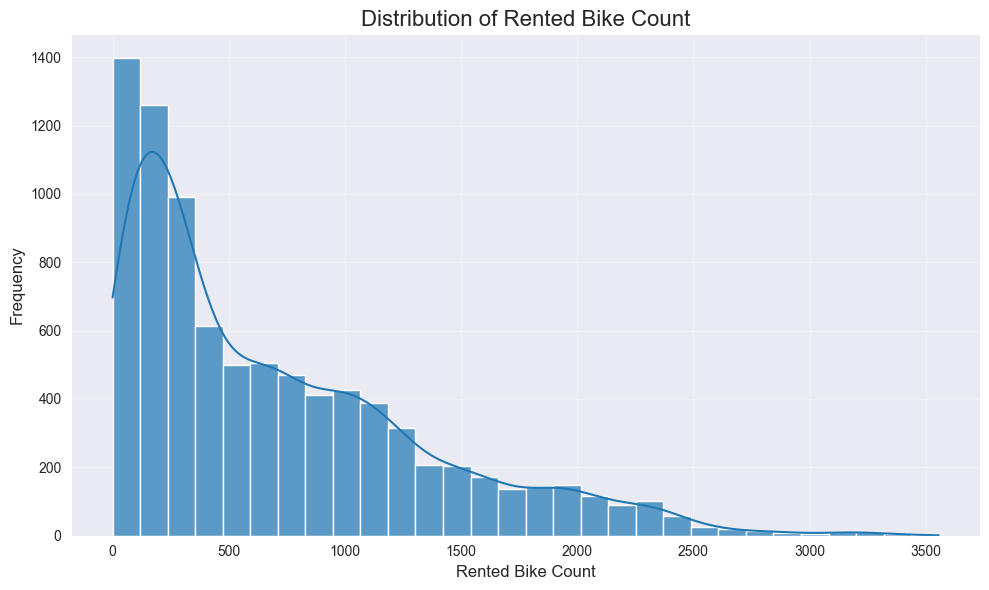

In [24]:
# Using seaborn for a more polished distribution plot
plt.figure(figsize=(10, 6))

# Histogram with KDE (kernel density estimation)
sns.histplot(data=rentals, x='Rented Bike Count', kde=True, bins=30, alpha=0.7)
plt.title('Distribution of Rented Bike Count', fontsize=16)
plt.xlabel('Rented Bike Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comprehensive Distribution Analysis

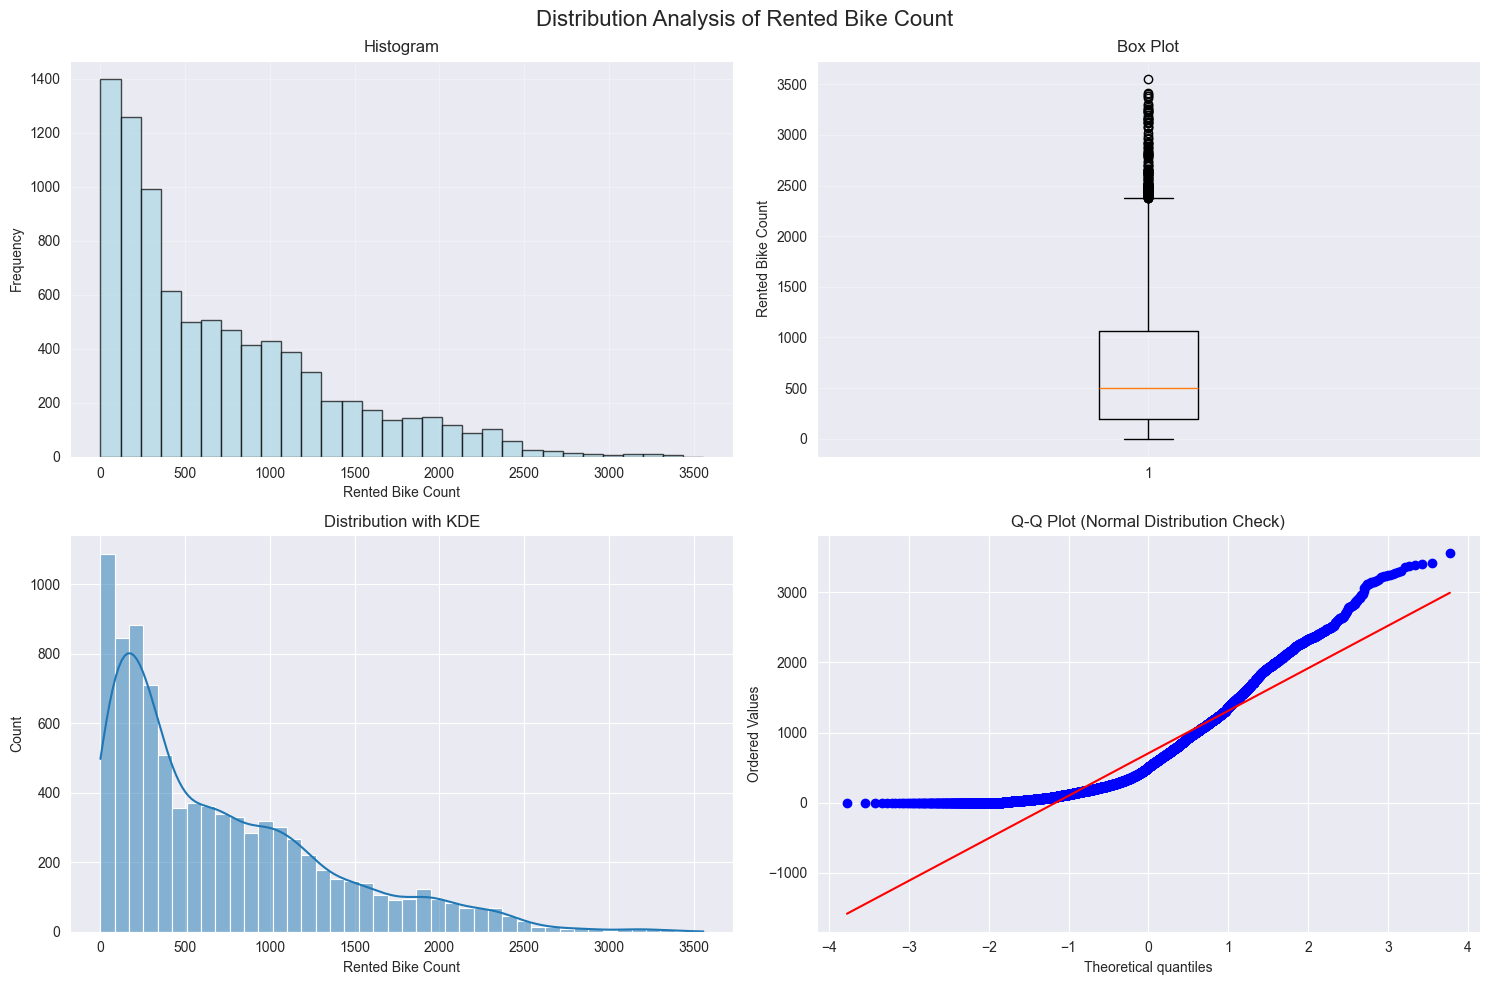

In [27]:
# Comprehensive distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(rentals['Rented Bike Count'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
axes[0, 0].set_title('Histogram')
axes[0, 0].set_xlabel('Rented Bike Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Box plot
axes[0, 1].boxplot(rentals['Rented Bike Count'])
axes[0, 1].set_title('Box Plot')
axes[0, 1].set_ylabel('Rented Bike Count')
axes[0, 1].grid(True, alpha=0.3)

# Distribution plot with KDE
sns.histplot(data=rentals, x='Rented Bike Count', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution with KDE')

# Q-Q plot to check normality
from scipy import stats
stats.probplot(rentals['Rented Bike Count'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal Distribution Check)')

plt.suptitle('Distribution Analysis of Rented Bike Count', fontsize=16)
plt.tight_layout()
plt.show()

## Plotting histograms for all numerical featuers

Numerical columns found: 10
['Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']


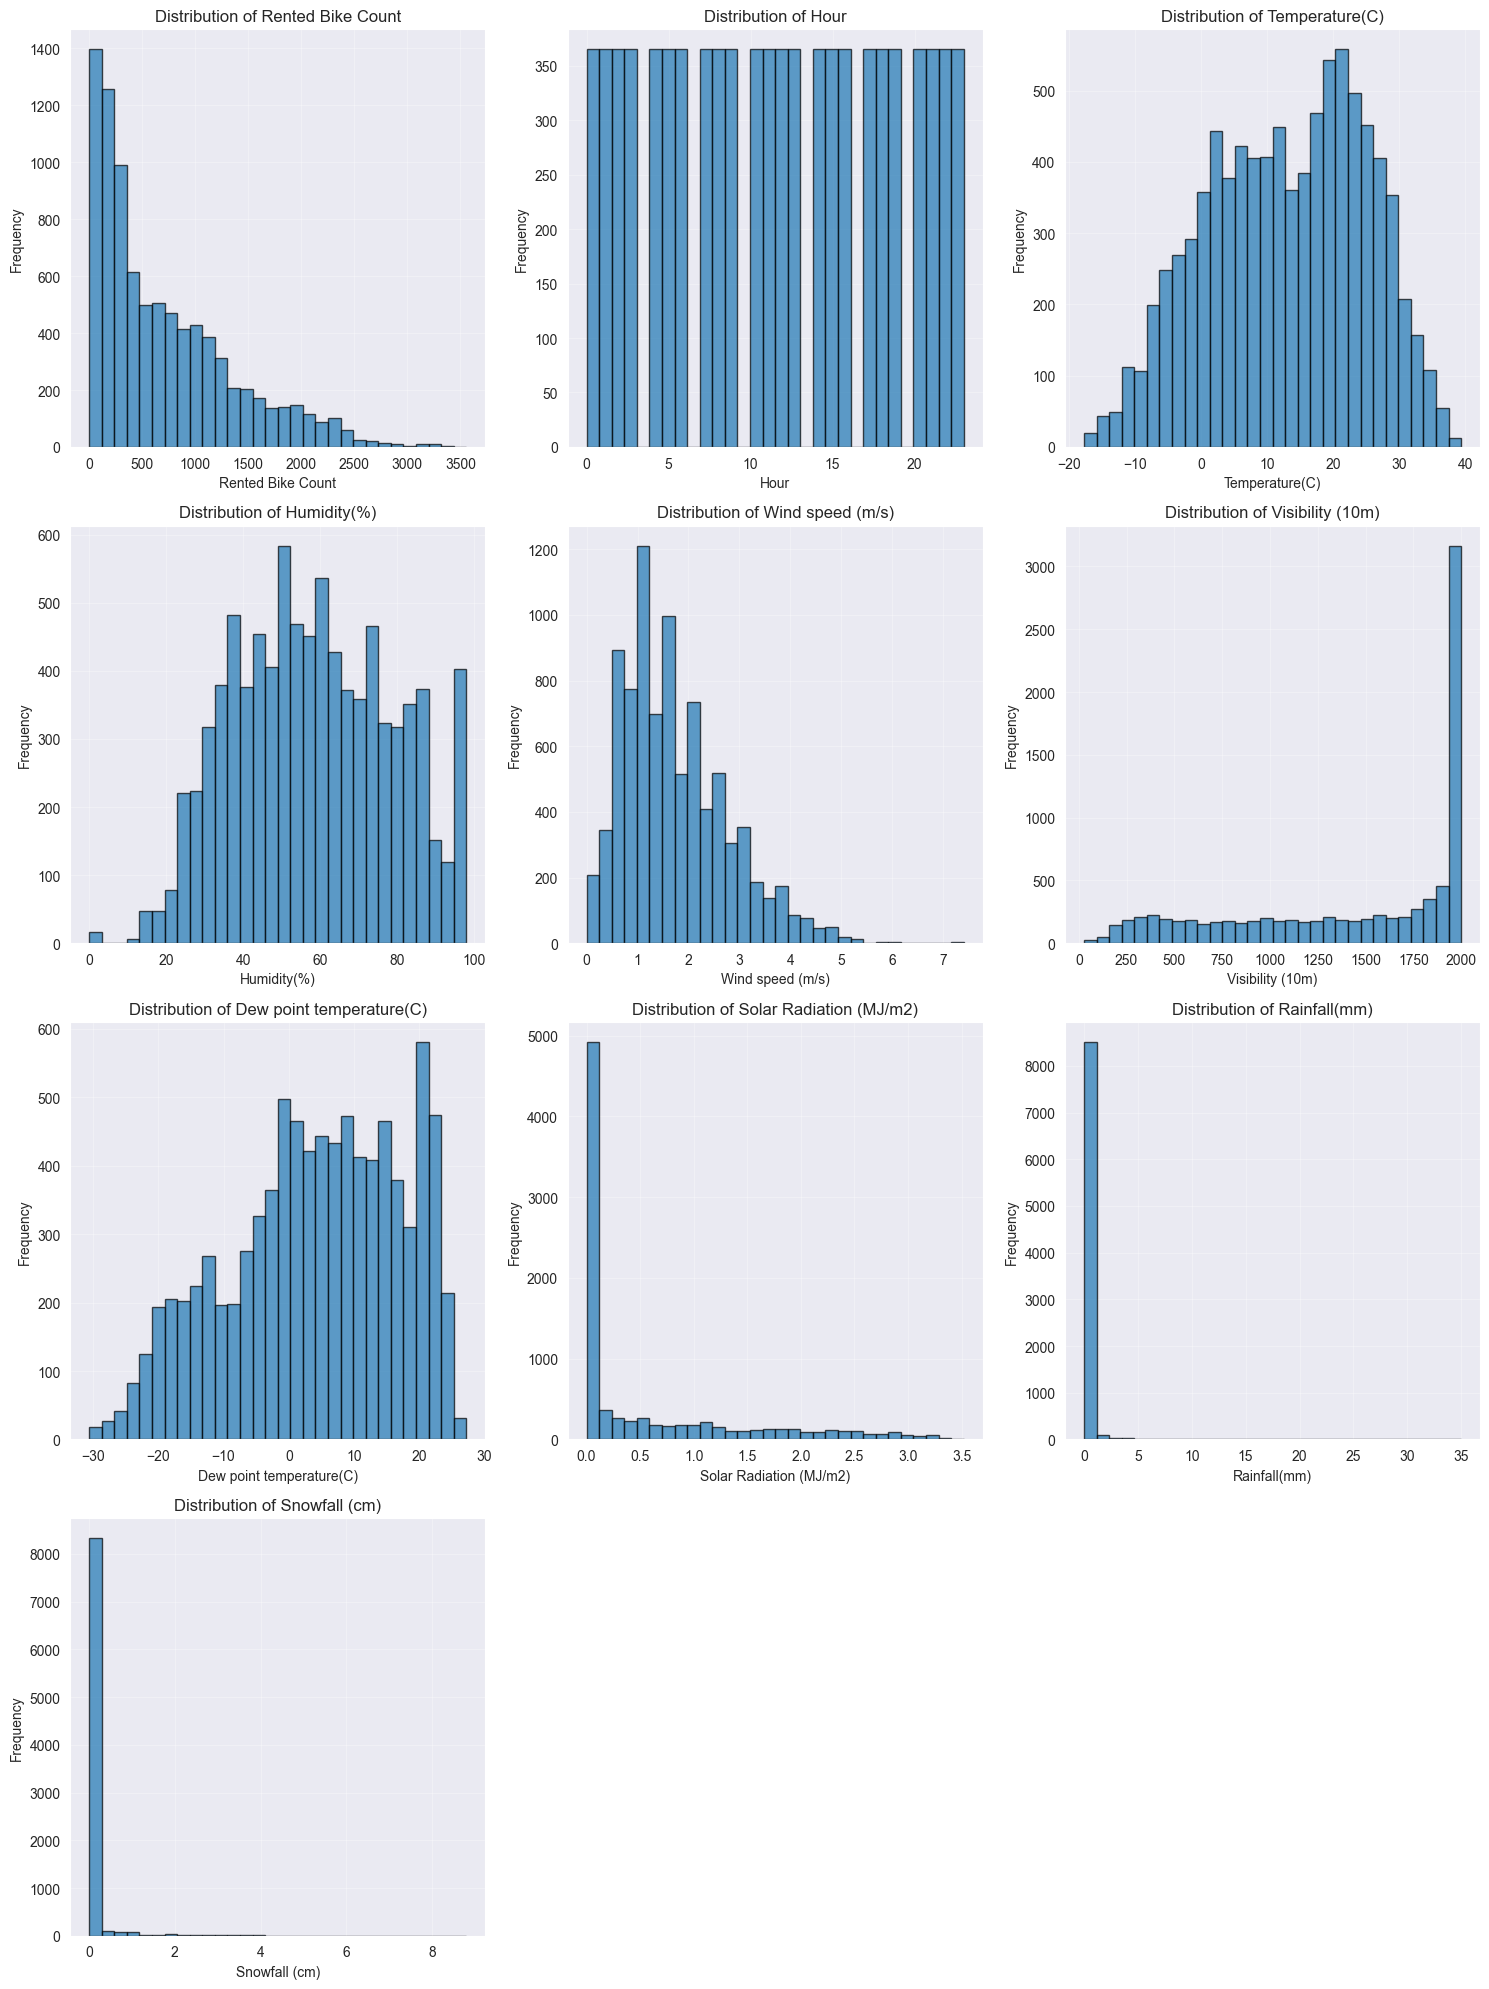

In [28]:
# Get all numerical columns
numerical_cols = rentals.select_dtypes(include=[np.number]).columns
print(f"Numerical columns found: {len(numerical_cols)}")
print(numerical_cols.tolist())

# Create subplots - adjust grid size based on number of features
n_cols = len(numerical_cols)
n_rows = (n_cols + 2) // 3  # 3 columns per row
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

# Create histogram for each numerical feature
for i, col in enumerate(numerical_cols):
    axes[i].hist(rentals[col], bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

# Hide empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

##  • Plot the box plot of Rented Bike Count against all the categorical features (Hint: Categorical
 features on X-axis and Rented Bike Count on Y-axis)


Categorical columns found: 4
['Date', 'Seasons', 'Holiday', 'Functioning Day']


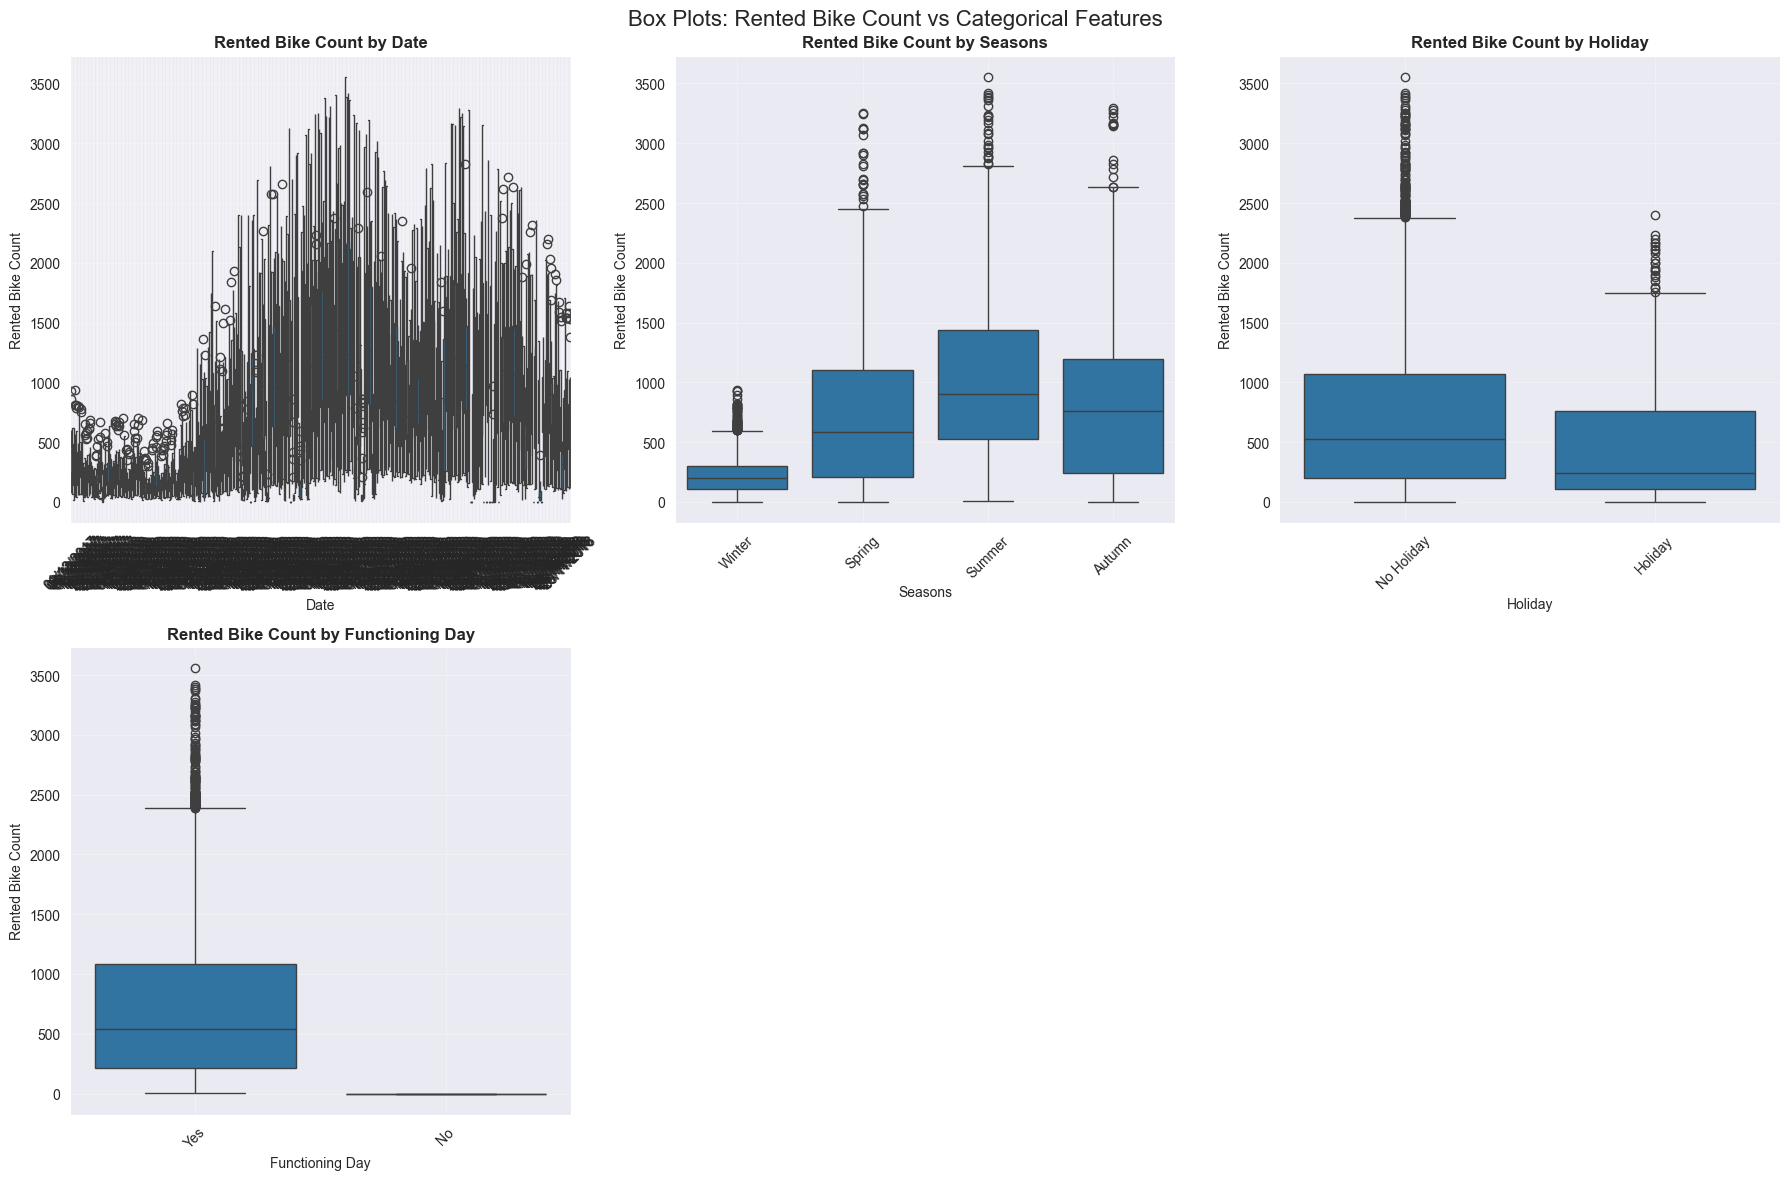

In [29]:
# First, identify categorical features
categorical_cols = rentals.select_dtypes(include=['object', 'category']).columns
print(f"Categorical columns found: {len(categorical_cols)}")
print(categorical_cols.tolist())

# Create box plots for each categorical feature
if len(categorical_cols) > 0:
    n_cols = len(categorical_cols)
    n_rows = (n_cols + 2) // 3  # 3 columns per row

    fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes

    for i, cat_col in enumerate(categorical_cols):
        sns.boxplot(data=rentals, x=cat_col, y='Rented Bike Count', ax=axes[i])
        axes[i].set_title(f'Rented Bike Count by {cat_col}', fontsize=12, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(True, alpha=0.3)

    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Box Plots: Rented Bike Count vs Categorical Features', fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found in the dataset")

## The next step is
• Plot the Seaborn catplot of Rented Bike Count against features like Hour, Holiday, Rainfall
(mm), Snowfall (cm), weekdays, weekend, and give your inferences.


## ploting seaborn catplots for specified features and their patterns

/Users/rlogwood/src/repos/fullstack/fs-assignments/.venv/lib/python3.12/site-packages/seaborn/categorical.py:2761: UserWarning: catplot is a figure-level function and does not accept target axes. You may wish to try boxplot
  warnings.warn(msg, UserWarning)


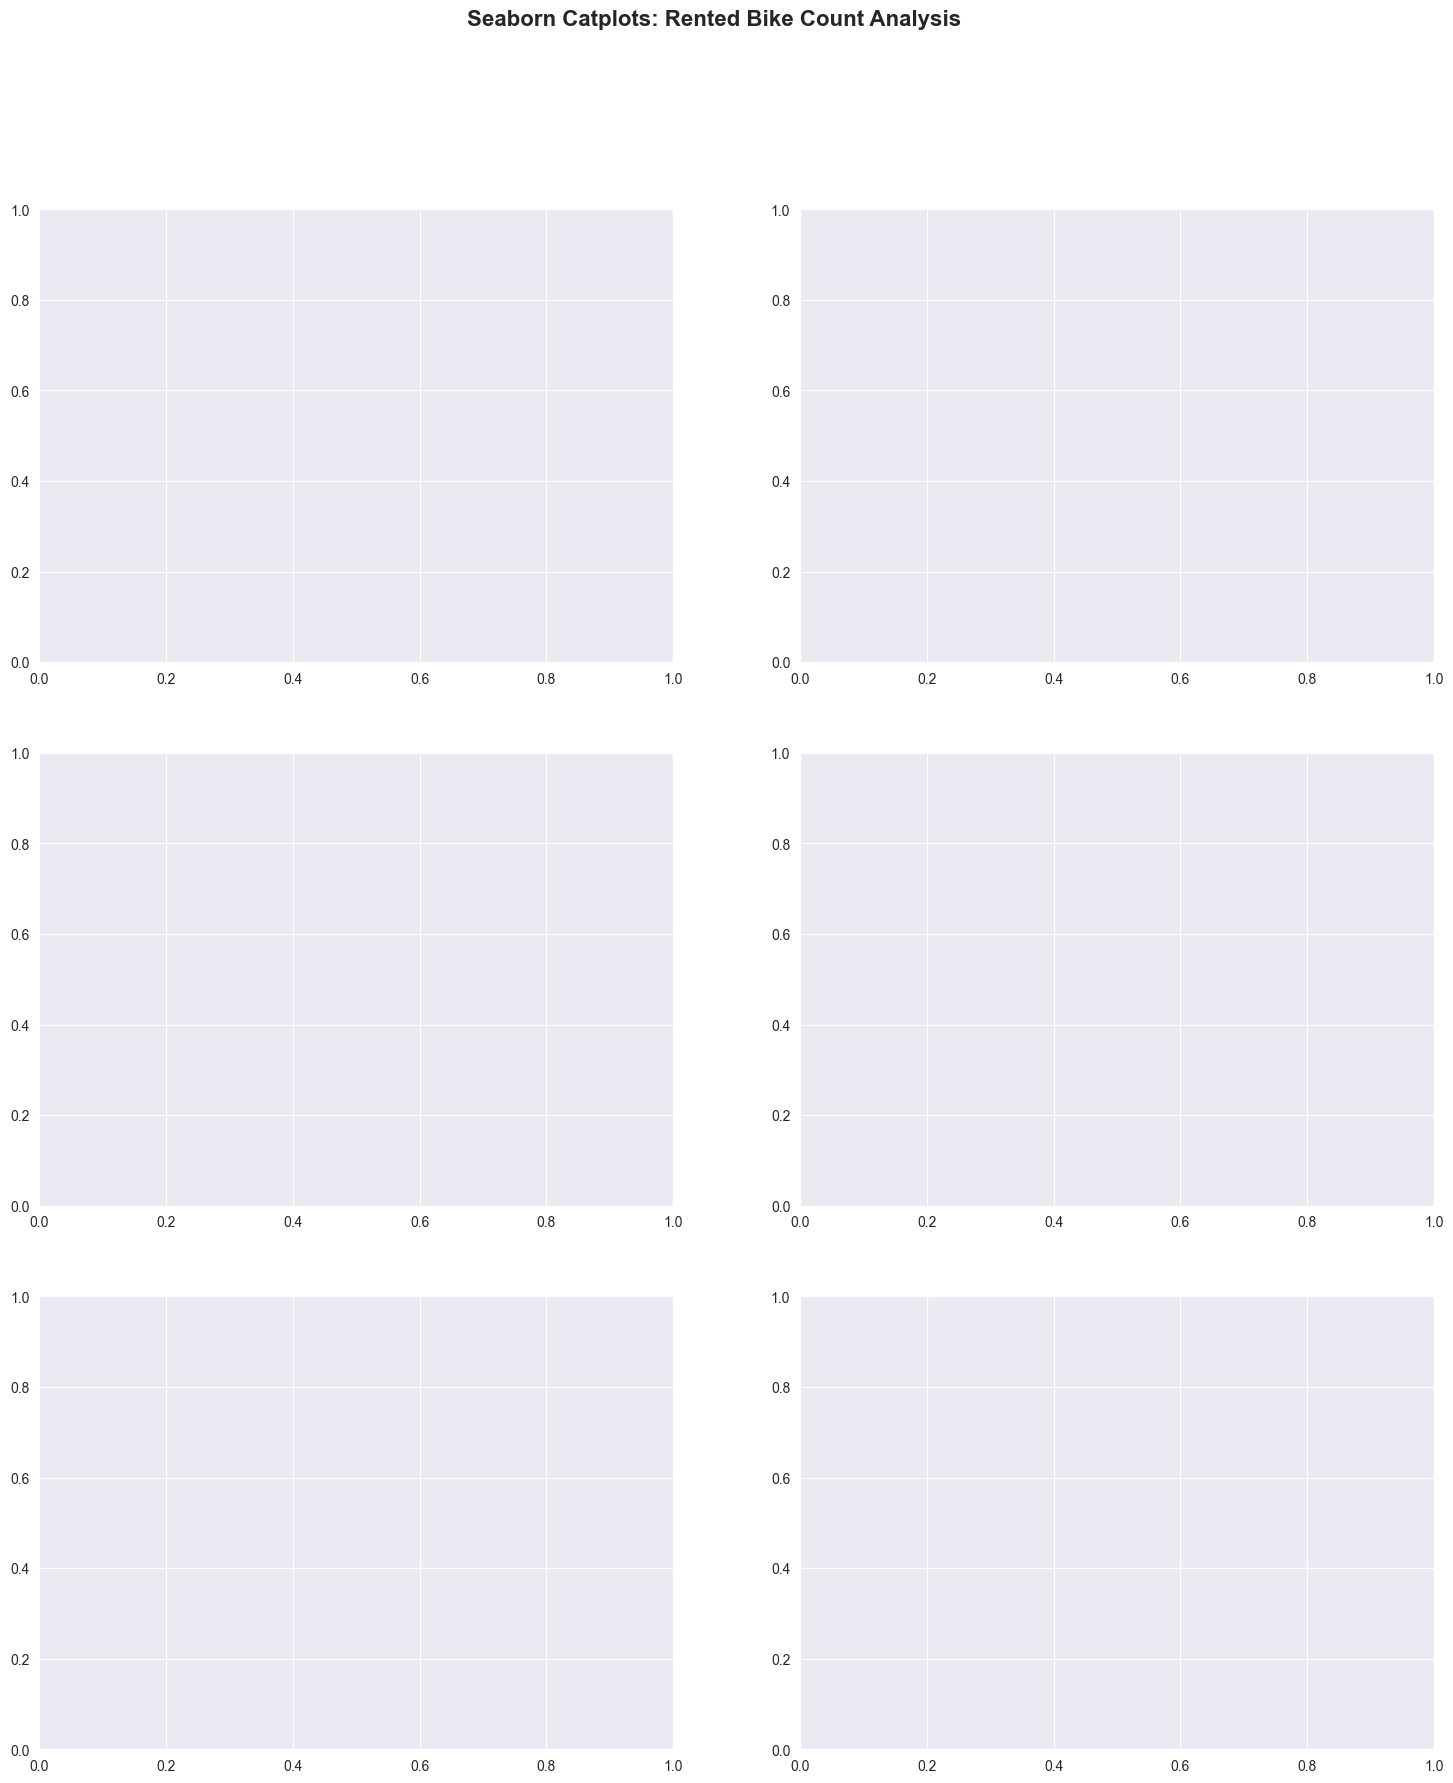

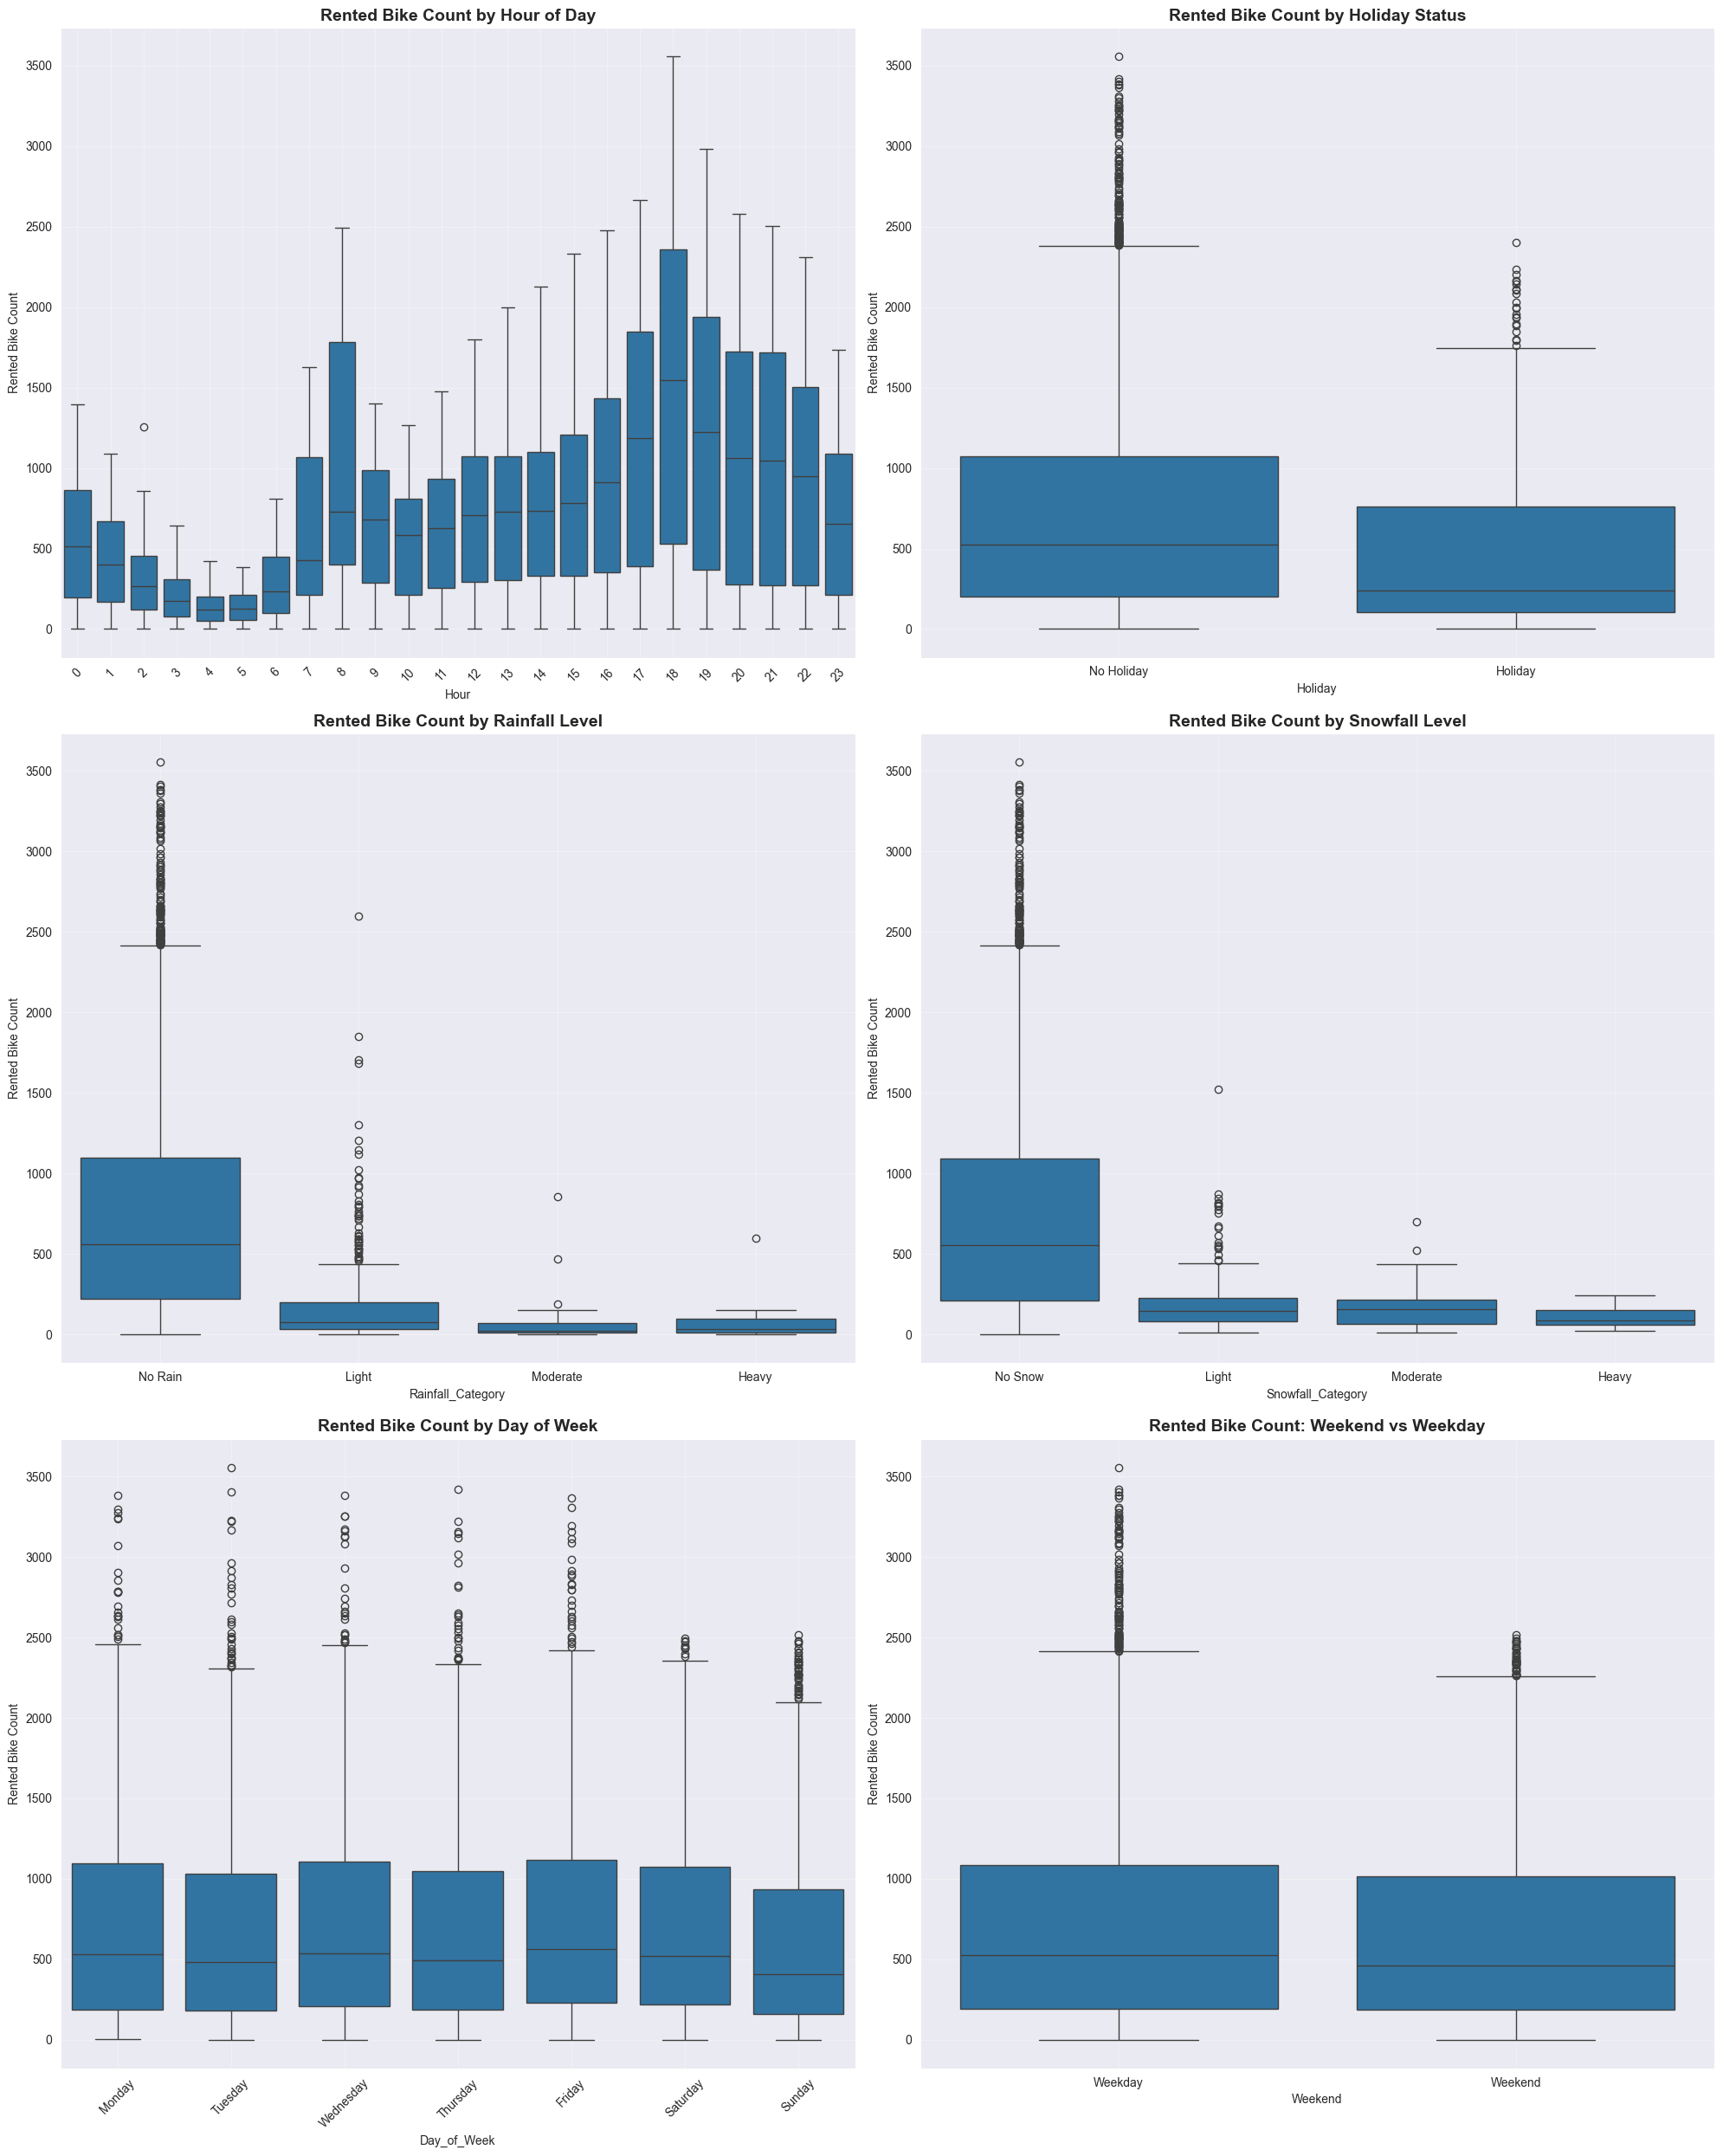


DETAILED ANALYSIS AND INFERENCES

1. HOURLY PATTERNS:
         mean  median      std
Hour                          
0      541.46   513.0   364.57
1      426.18   401.0   285.53
2      301.63   265.0   210.11
3      203.33   176.0   143.20
4      132.59   119.0    90.27
5      139.08   129.0    95.52
6      287.56   232.0   222.82
7      606.01   426.0   482.26
8     1015.70   728.0   761.59
9      645.98   680.0   398.65
10     527.82   581.0   323.01
11     600.85   624.0   361.96
12     699.44   709.0   430.74
13     733.25   727.0   457.72
14     758.82   733.0   488.85
15     829.19   785.0   546.47
16     930.62   911.0   618.02
17    1138.51  1184.0   748.95
18    1502.93  1548.0  1029.30
19    1195.15  1224.0   857.42
20    1068.96  1062.0   793.90
21    1031.45  1046.0   753.65
22     922.80   949.0   660.79
23     671.13   656.0   478.78
Peak demand hour: 18 (avg: 1502.93 rentals)
Lowest demand hour: 4 (avg: 132.59 rentals)

2. WEEKEND vs WEEKDAY PATTERNS:
           mean  m

/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_13528/215514525.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rainfall_stats = rentals_cat.groupby('Rainfall_Category')['Rented Bike Count'].agg(['mean', 'count']).round(2)
/var/folders/dx/86cvpn0169sd3sqctx9wcxgr0000gn/T/ipykernel_13528/215514525.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snowfall_stats = rentals_cat.groupby('Snowfall_Category')['Rented Bike Count'].agg(['mean', 'count']).round(2)


In [30]:
# First, prepare the data with necessary categorical features
rentals_cat = rentals.copy()

# Create weekend/weekday feature from DateTime if available
if 'DateTime' in rentals_cat.columns:
    rentals_cat['Weekend'] = (rentals_cat['DateTime'].dt.weekday >= 5).map({True: 'Weekend', False: 'Weekday'})
    rentals_cat['Day_of_Week'] = rentals_cat['DateTime'].dt.day_name()

# Create categorical bins for continuous features
# Rainfall categories
if 'Rainfall(mm)' in rentals_cat.columns:
    rentals_cat['Rainfall_Category'] = pd.cut(rentals_cat['Rainfall(mm)'],
                                             bins=[-0.1, 0, 5, 15, float('inf')],
                                             labels=['No Rain', 'Light', 'Moderate', 'Heavy'])

# Snowfall categories
if 'Snowfall (cm)' in rentals_cat.columns:
    rentals_cat['Snowfall_Category'] = pd.cut(rentals_cat['Snowfall (cm)'],
                                              bins=[-0.1, 0, 2, 5, float('inf')],
                                              labels=['No Snow', 'Light', 'Moderate', 'Heavy'])

# Create catplots
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Seaborn Catplots: Rented Bike Count Analysis', fontsize=16, fontweight='bold')

# 1. Hour vs Rented Bike Count
plt.subplot(3, 2, 1)
sns.catplot(data=rentals_cat, x='Hour', y='Rented Bike Count', kind='box', ax=plt.gca())
plt.title('Rented Bike Count by Hour of Day')
plt.xticks(rotation=45)
plt.close()  # Close the extra figure created by catplot

# Let's use a simpler approach with individual plots
plt.figure(figsize=(20, 25))

# 1. Hour vs Rented Bike Count
plt.subplot(3, 2, 1)
sns.boxplot(data=rentals_cat, x='Hour', y='Rented Bike Count')
plt.title('Rented Bike Count by Hour of Day', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2. Holiday vs Rented Bike Count (if Holiday column exists)
plt.subplot(3, 2, 2)
if 'Holiday' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Holiday', y='Rented Bike Count')
    plt.title('Rented Bike Count by Holiday Status', fontsize=14, fontweight='bold')
else:
    # Create a mock holiday feature or use weekend as proxy
    sns.boxplot(data=rentals_cat, x='Weekend', y='Rented Bike Count')
    plt.title('Rented Bike Count by Weekend/Weekday', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 3. Rainfall Category vs Rented Bike Count
plt.subplot(3, 2, 3)
if 'Rainfall_Category' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Rainfall_Category', y='Rented Bike Count')
    plt.title('Rented Bike Count by Rainfall Level', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 4. Snowfall Category vs Rented Bike Count
plt.subplot(3, 2, 4)
if 'Snowfall_Category' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Snowfall_Category', y='Rented Bike Count')
    plt.title('Rented Bike Count by Snowfall Level', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# 5. Day of Week vs Rented Bike Count
plt.subplot(3, 2, 5)
if 'Day_of_Week' in rentals_cat.columns:
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(data=rentals_cat, x='Day_of_Week', y='Rented Bike Count', order=days_order)
    plt.title('Rented Bike Count by Day of Week', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 6. Weekend vs Weekday
plt.subplot(3, 2, 6)
if 'Weekend' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Weekend', y='Rented Bike Count')
    plt.title('Rented Bike Count: Weekend vs Weekday', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics for insights
print("\n" + "="*60)
print("DETAILED ANALYSIS AND INFERENCES")
print("="*60)

# Hour analysis
print("\n1. HOURLY PATTERNS:")
hourly_stats = rentals_cat.groupby('Hour')['Rented Bike Count'].agg(['mean', 'median', 'std']).round(2)
print(hourly_stats)
peak_hour = hourly_stats['mean'].idxmax()
lowest_hour = hourly_stats['mean'].idxmin()
print(f"Peak demand hour: {peak_hour} (avg: {hourly_stats.loc[peak_hour, 'mean']} rentals)")
print(f"Lowest demand hour: {lowest_hour} (avg: {hourly_stats.loc[lowest_hour, 'mean']} rentals)")

# Weekend vs Weekday analysis
if 'Weekend' in rentals_cat.columns:
    print("\n2. WEEKEND vs WEEKDAY PATTERNS:")
    weekend_stats = rentals_cat.groupby('Weekend')['Rented Bike Count'].agg(['mean', 'median', 'count']).round(2)
    print(weekend_stats)

# Day of week analysis
if 'Day_of_Week' in rentals_cat.columns:
    print("\n3. DAY OF WEEK PATTERNS:")
    daily_stats = rentals_cat.groupby('Day_of_Week')['Rented Bike Count'].mean().round(2)
    print(daily_stats.sort_values(ascending=False))

# Weather impact analysis
if 'Rainfall_Category' in rentals_cat.columns:
    print("\n4. RAINFALL IMPACT:")
    rainfall_stats = rentals_cat.groupby('Rainfall_Category')['Rented Bike Count'].agg(['mean', 'count']).round(2)
    print(rainfall_stats)

if 'Snowfall_Category' in rentals_cat.columns:
    print("\n5. SNOWFALL IMPACT:")
    snowfall_stats = rentals_cat.groupby('Snowfall_Category')['Rented Bike Count'].agg(['mean', 'count']).round(2)
    print(snowfall_stats)

## Fixed version

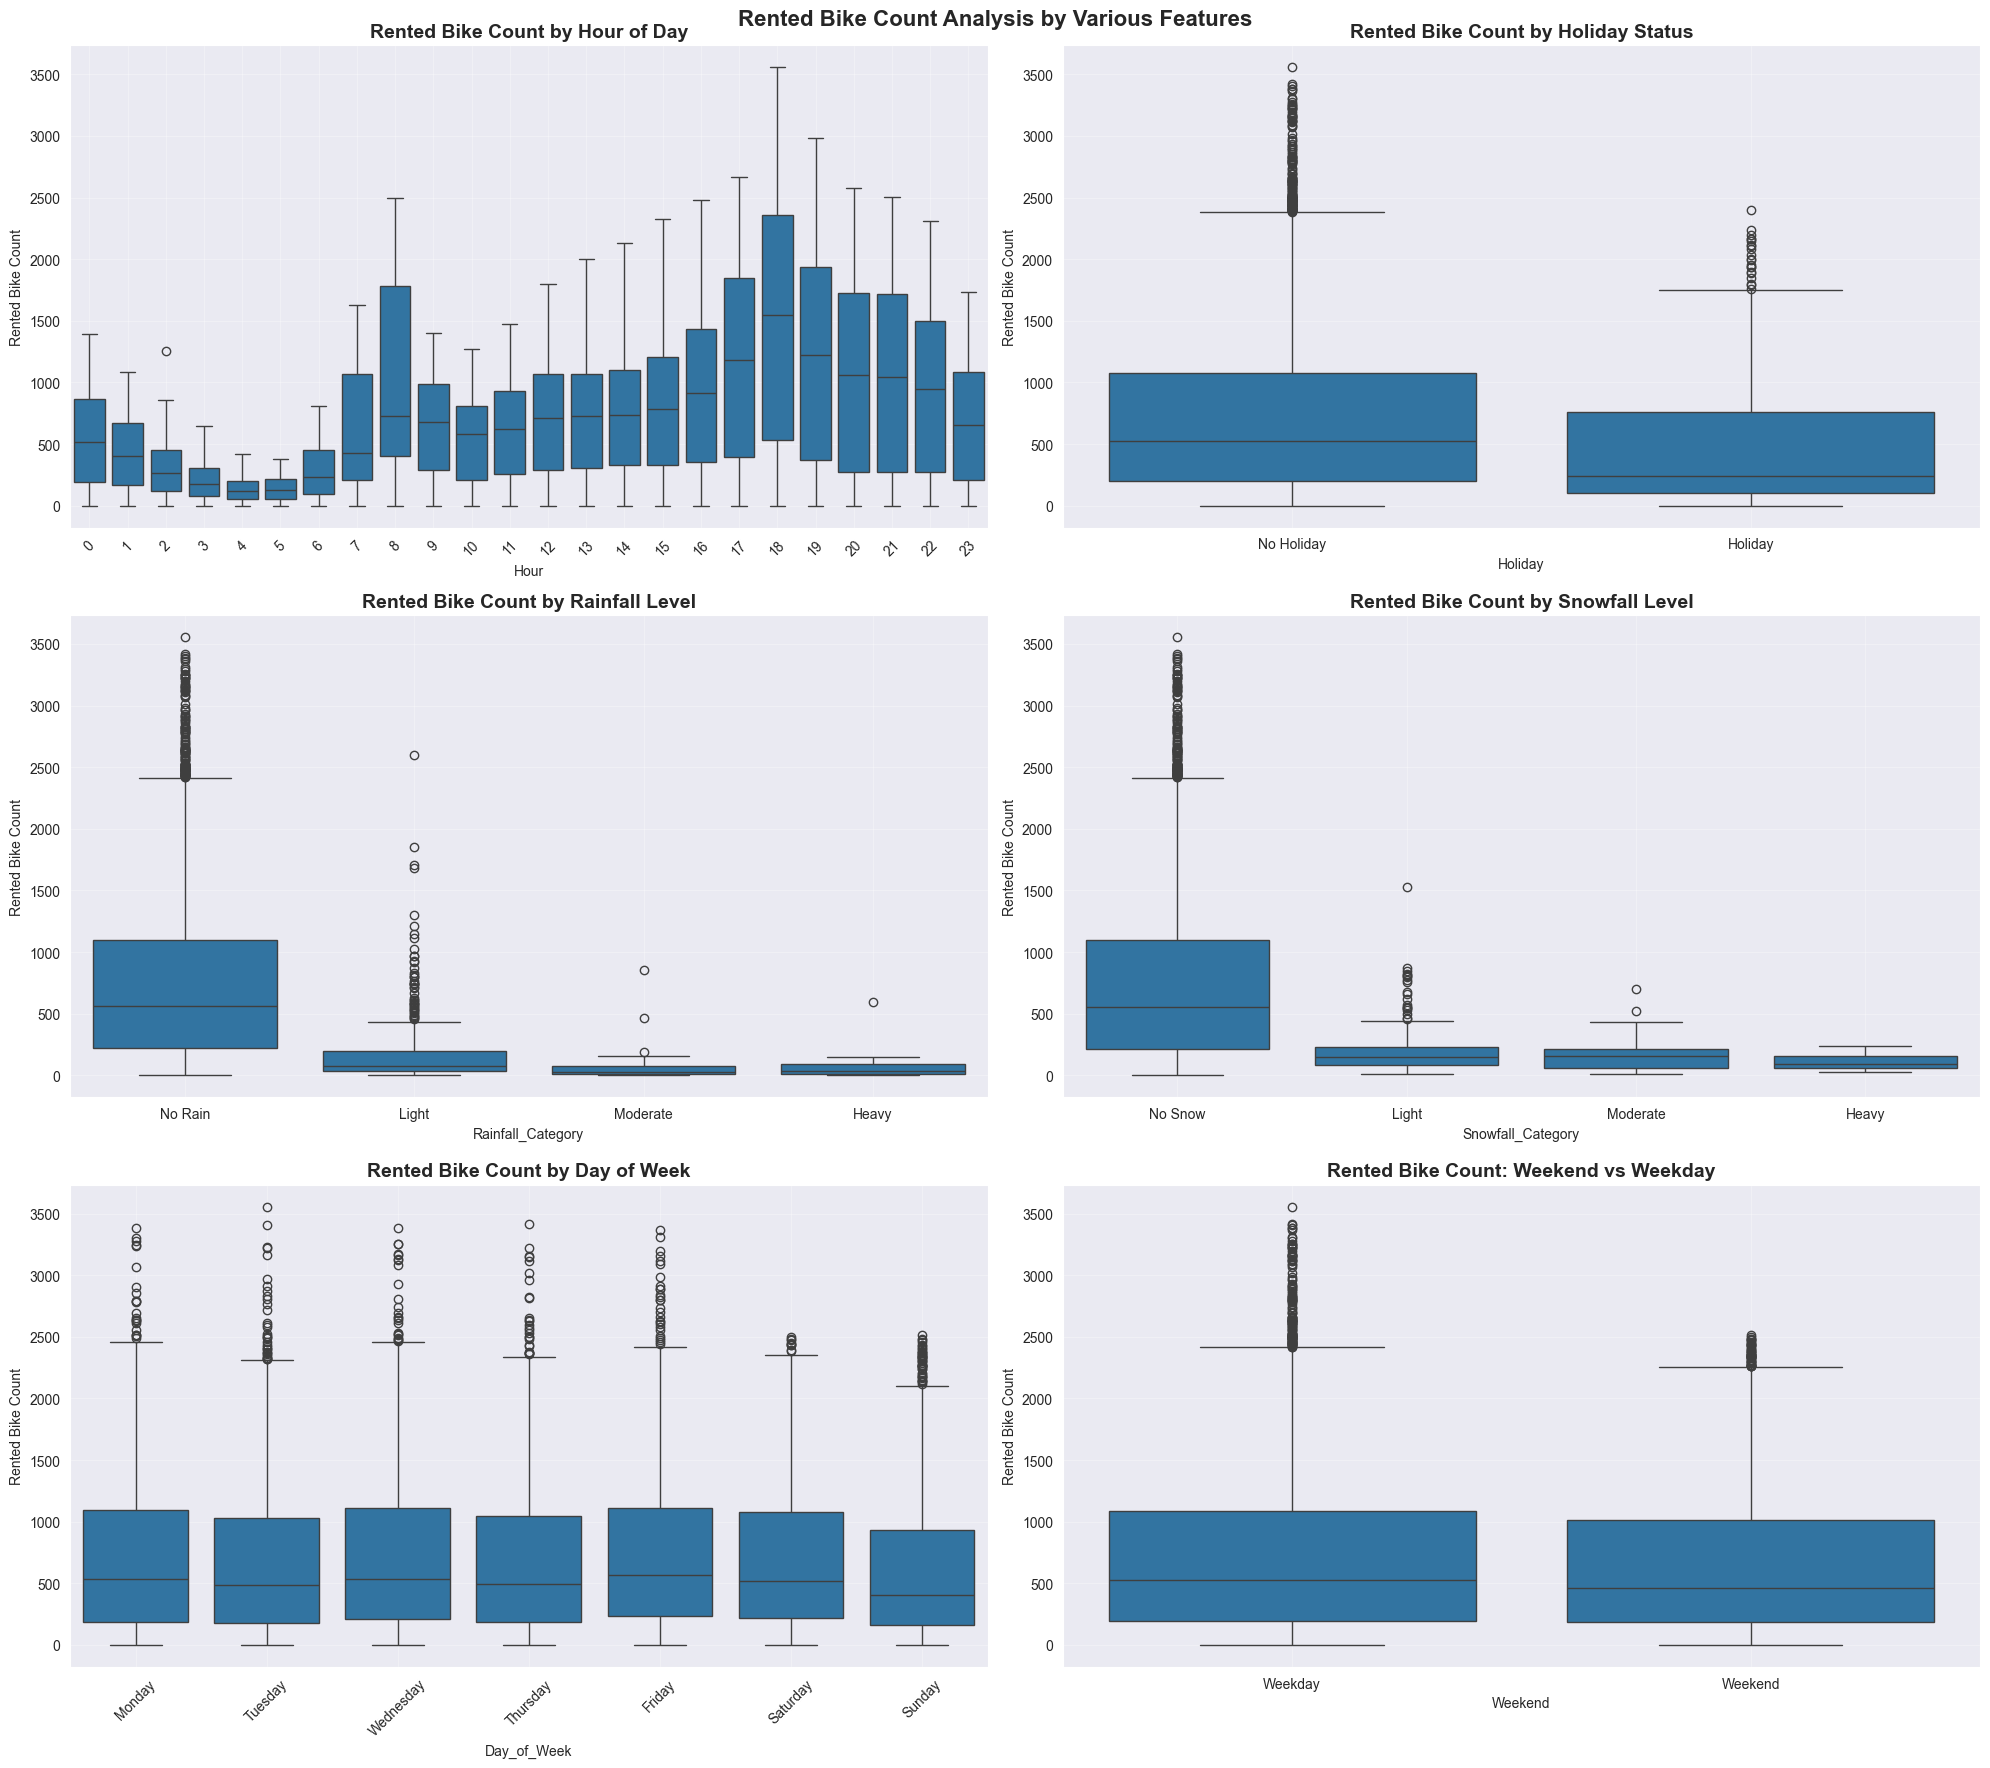


DETAILED ANALYSIS AND INFERENCES

1. HOURLY PATTERNS:
         mean  median      std
Hour                          
0      541.46   513.0   364.57
1      426.18   401.0   285.53
2      301.63   265.0   210.11
3      203.33   176.0   143.20
4      132.59   119.0    90.27
5      139.08   129.0    95.52
6      287.56   232.0   222.82
7      606.01   426.0   482.26
8     1015.70   728.0   761.59
9      645.98   680.0   398.65
10     527.82   581.0   323.01
11     600.85   624.0   361.96
12     699.44   709.0   430.74
13     733.25   727.0   457.72
14     758.82   733.0   488.85
15     829.19   785.0   546.47
16     930.62   911.0   618.02
17    1138.51  1184.0   748.95
18    1502.93  1548.0  1029.30
19    1195.15  1224.0   857.42
20    1068.96  1062.0   793.90
21    1031.45  1046.0   753.65
22     922.80   949.0   660.79
23     671.13   656.0   478.78
Peak demand hour: 18 (avg: 1502.93 rentals)
Lowest demand hour: 4 (avg: 132.59 rentals)

2. WEEKEND vs WEEKDAY PATTERNS:
           mean  m

In [33]:
# First, prepare the data with necessary categorical features
rentals_cat = rentals.copy()

# Create weekend/weekday feature from DateTime if available
if 'DateTime' in rentals_cat.columns:
    rentals_cat['Weekend'] = (rentals_cat['DateTime'].dt.weekday >= 5).map({True: 'Weekend', False: 'Weekday'})
    rentals_cat['Day_of_Week'] = rentals_cat['DateTime'].dt.day_name()

# Create categorical bins for continuous features
# Rainfall categories
if 'Rainfall(mm)' in rentals_cat.columns:
    rentals_cat['Rainfall_Category'] = pd.cut(rentals_cat['Rainfall(mm)'],
                                             bins=[-0.1, 0, 5, 15, float('inf')],
                                             labels=['No Rain', 'Light', 'Moderate', 'Heavy'])

# Snowfall categories
if 'Snowfall (cm)' in rentals_cat.columns:
    rentals_cat['Snowfall_Category'] = pd.cut(rentals_cat['Snowfall (cm)'],
                                              bins=[-0.1, 0, 2, 5, float('inf')],
                                              labels=['No Snow', 'Light', 'Moderate', 'Heavy'])

# Create individual plots using matplotlib subplots (not catplot)
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Rented Bike Count Analysis by Various Features', fontsize=16, fontweight='bold')

# 1. Hour vs Rented Bike Count
sns.boxplot(data=rentals_cat, x='Hour', y='Rented Bike Count', ax=axes[0, 0])
axes[0, 0].set_title('Rented Bike Count by Hour of Day', fontsize=14, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Holiday vs Rented Bike Count (using Weekend as proxy if Holiday doesn't exist)
if 'Holiday' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Holiday', y='Rented Bike Count', ax=axes[0, 1])
    axes[0, 1].set_title('Rented Bike Count by Holiday Status', fontsize=14, fontweight='bold')
elif 'Weekend' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Weekend', y='Rented Bike Count', ax=axes[0, 1])
    axes[0, 1].set_title('Rented Bike Count by Weekend/Weekday', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Rainfall Category vs Rented Bike Count
if 'Rainfall_Category' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Rainfall_Category', y='Rented Bike Count', ax=axes[1, 0])
    axes[1, 0].set_title('Rented Bike Count by Rainfall Level', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

# 4. Snowfall Category vs Rented Bike Count
if 'Snowfall_Category' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Snowfall_Category', y='Rented Bike Count', ax=axes[1, 1])
    axes[1, 1].set_title('Rented Bike Count by Snowfall Level', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

# 5. Day of Week vs Rented Bike Count
if 'Day_of_Week' in rentals_cat.columns:
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    sns.boxplot(data=rentals_cat, x='Day_of_Week', y='Rented Bike Count', order=days_order, ax=axes[2, 0])
    axes[2, 0].set_title('Rented Bike Count by Day of Week', fontsize=14, fontweight='bold')
    axes[2, 0].tick_params(axis='x', rotation=45)
    axes[2, 0].grid(True, alpha=0.3)

# 6. Weekend vs Weekday (detailed view)
if 'Weekend' in rentals_cat.columns:
    sns.boxplot(data=rentals_cat, x='Weekend', y='Rented Bike Count', ax=axes[2, 1])
    axes[2, 1].set_title('Rented Bike Count: Weekend vs Weekday', fontsize=14, fontweight='bold')
    axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed statistics for insights (with observed=True to fix warning)
print("\n" + "="*60)
print("DETAILED ANALYSIS AND INFERENCES")
print("="*60)

# Hour analysis
print("\n1. HOURLY PATTERNS:")
hourly_stats = rentals_cat.groupby('Hour', observed=True)['Rented Bike Count'].agg(['mean', 'median', 'std']).round(2)
print(hourly_stats)
peak_hour = hourly_stats['mean'].idxmax()
lowest_hour = hourly_stats['mean'].idxmin()
print(f"Peak demand hour: {peak_hour} (avg: {hourly_stats.loc[peak_hour, 'mean']} rentals)")
print(f"Lowest demand hour: {lowest_hour} (avg: {hourly_stats.loc[lowest_hour, 'mean']} rentals)")

# Weekend vs Weekday analysis
if 'Weekend' in rentals_cat.columns:
    print("\n2. WEEKEND vs WEEKDAY PATTERNS:")
    weekend_stats = rentals_cat.groupby('Weekend', observed=True)['Rented Bike Count'].agg(['mean', 'median', 'count']).round(2)
    print(weekend_stats)

# Day of week analysis
if 'Day_of_Week' in rentals_cat.columns:
    print("\n3. DAY OF WEEK PATTERNS:")
    daily_stats = rentals_cat.groupby('Day_of_Week', observed=True)['Rented Bike Count'].mean().round(2)
    print(daily_stats.sort_values(ascending=False))

# Weather impact analysis
if 'Rainfall_Category' in rentals_cat.columns:
    print("\n4. RAINFALL IMPACT:")
    rainfall_stats = rentals_cat.groupby('Rainfall_Category', observed=True)['Rented Bike Count'].agg(['mean', 'count']).round(2)
    print(rainfall_stats)

if 'Snowfall_Category' in rentals_cat.columns:
    print("\n5. SNOWFALL IMPACT:")
    snowfall_stats = rentals_cat.groupby('Snowfall_Category', observed=True)['Rented Bike Count'].agg(['mean', 'count']).round(2)
    print(snowfall_stats)

## Alternative Approach using proper catplots

<Figure size 1200x600 with 0 Axes>

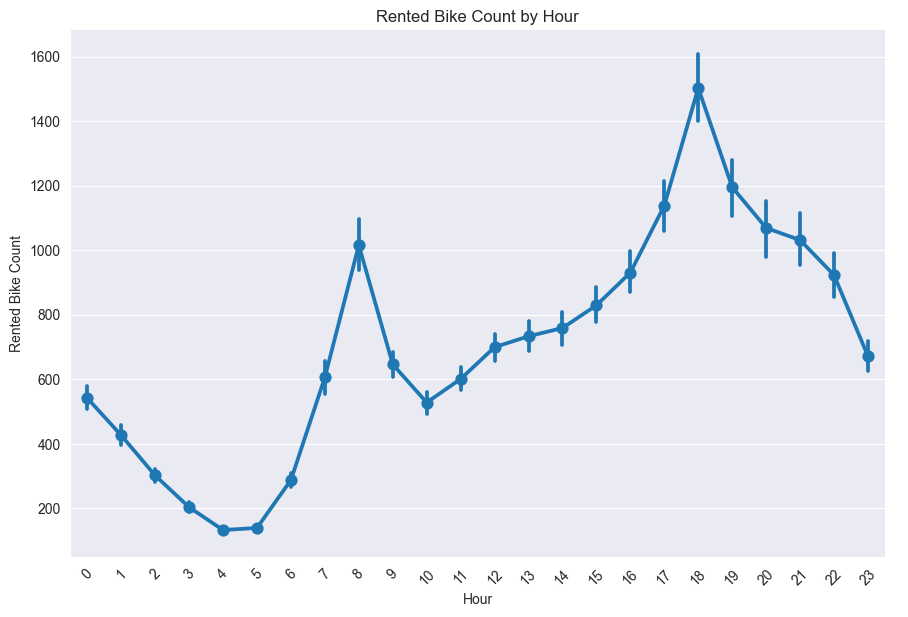

<Figure size 1200x600 with 0 Axes>

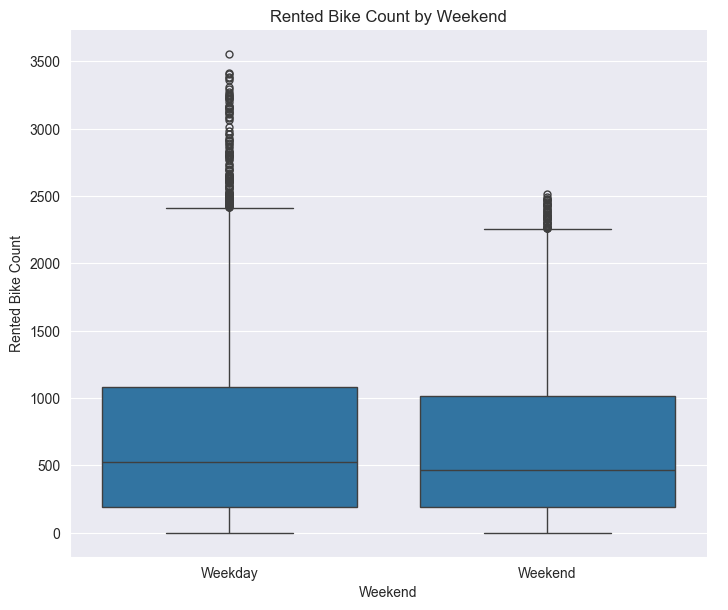

<Figure size 1200x600 with 0 Axes>

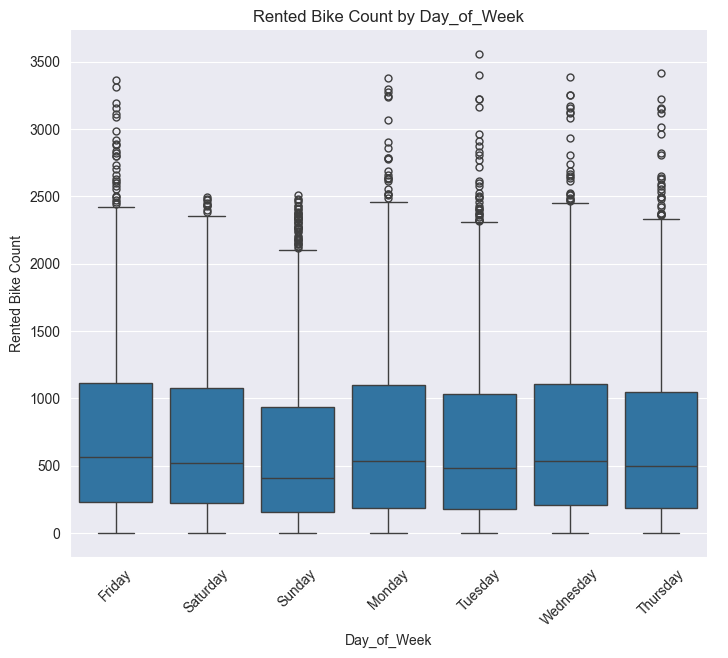

<Figure size 1200x600 with 0 Axes>

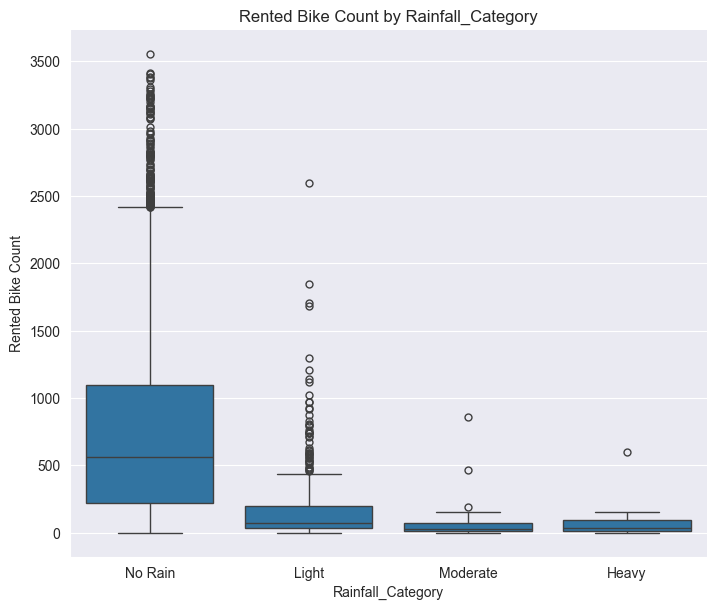

<Figure size 1200x600 with 0 Axes>

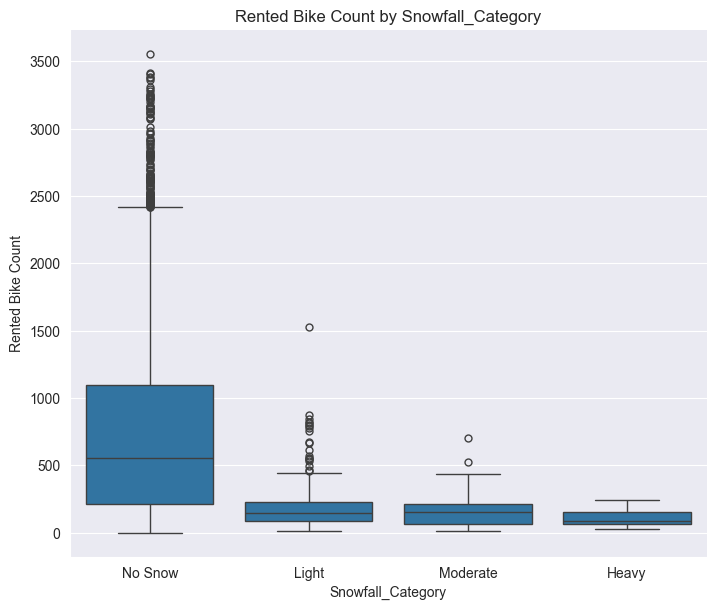

In [31]:
# Using seaborn catplot properly (creates separate figures)
features_to_plot = ['Hour', 'Weekend', 'Day_of_Week', 'Rainfall_Category', 'Snowfall_Category']

for feature in features_to_plot:
    if feature in rentals_cat.columns:
        plt.figure(figsize=(12, 6))

        if feature == 'Hour':
            # For Hour, use a line plot to show trend
            sns.catplot(data=rentals_cat, x=feature, y='Rented Bike Count',
                       kind='point', height=6, aspect=1.5)
        else:
            # For categorical features, use box plots
            sns.catplot(data=rentals_cat, x=feature, y='Rented Bike Count',
                       kind='box', height=6, aspect=1.2)

        plt.title(f'Rented Bike Count by {feature}')
        if feature in ['Day_of_Week', 'Hour']:
            plt.xticks(rotation=45)
        plt.show()

# Alternative: Using Proper Catplots (Separate Figures)

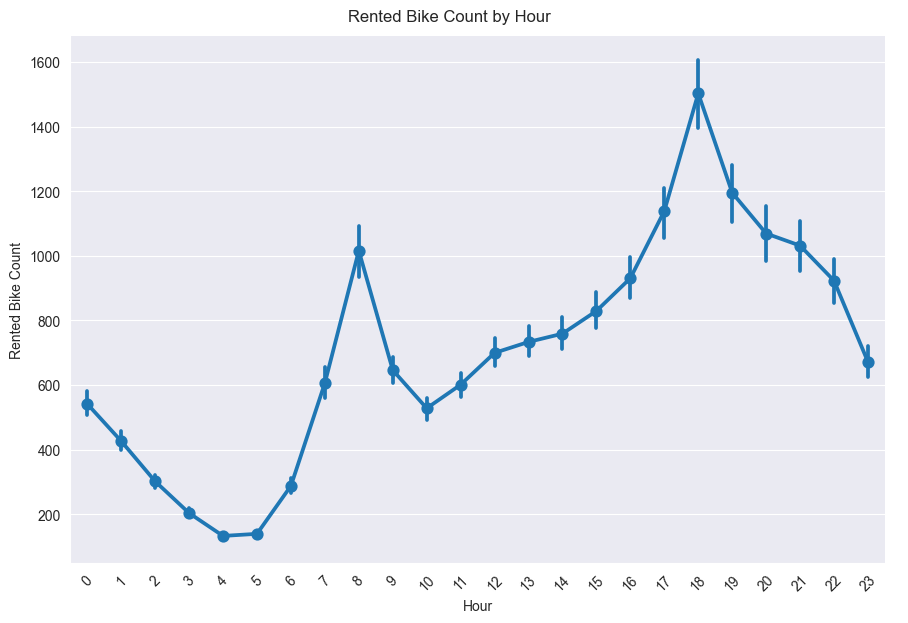

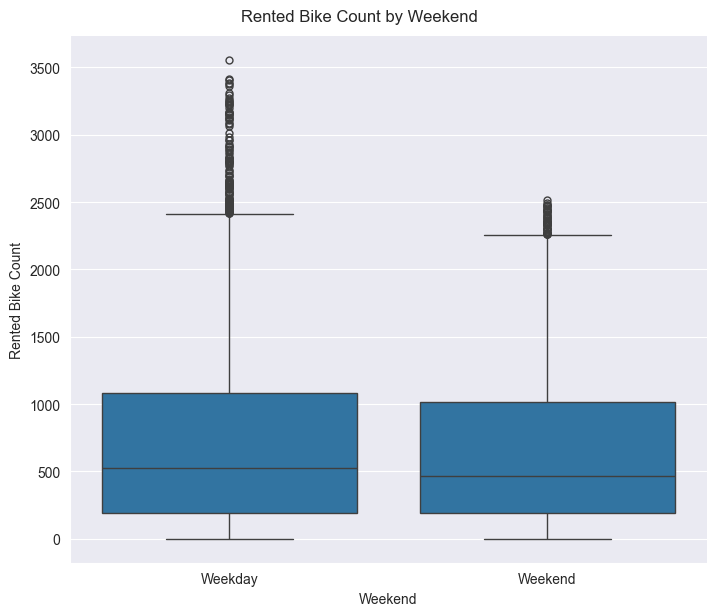

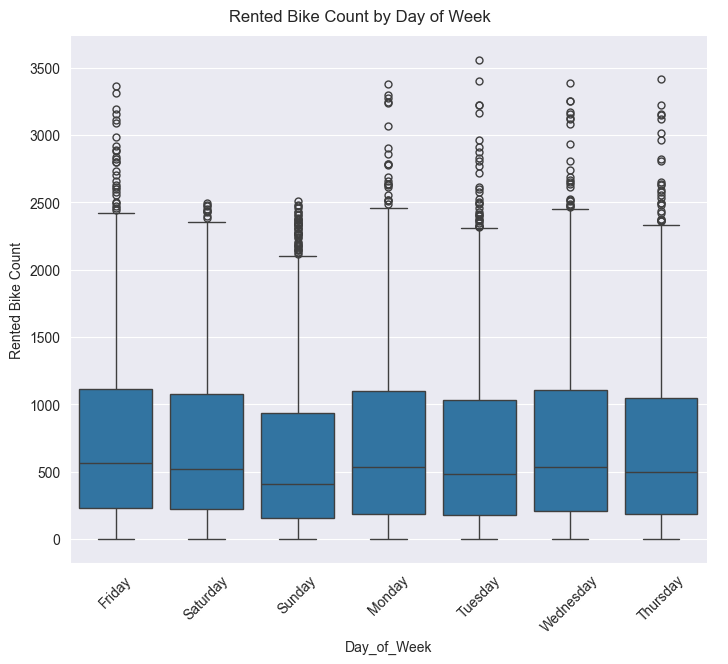

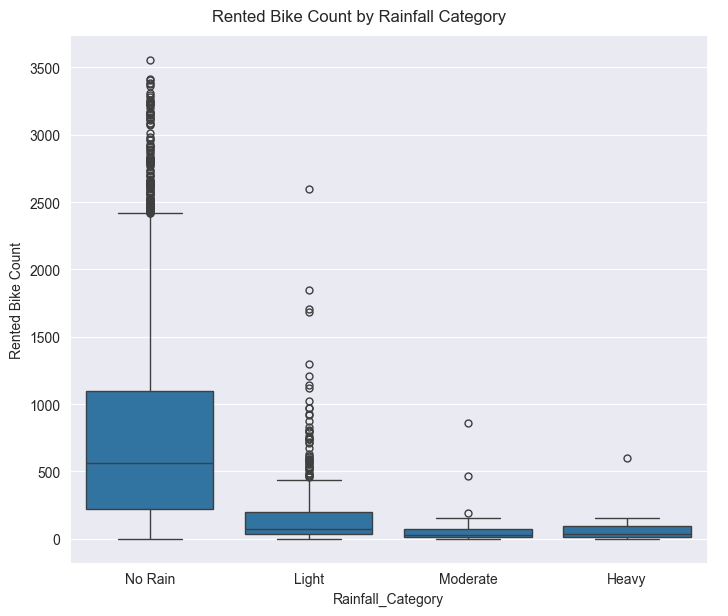

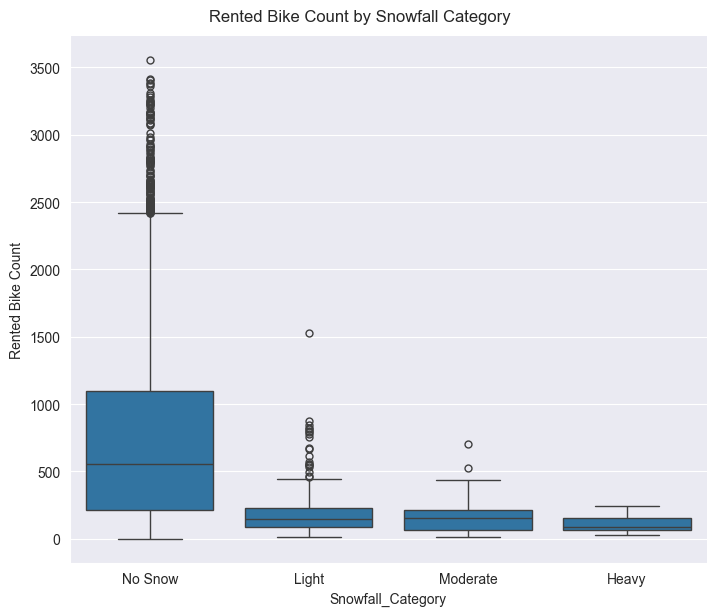

In [34]:
# Using seaborn catplot properly (creates separate figures)
features_to_plot = [
    ('Hour', 'Hour'),
    ('Weekend', 'Weekend') if 'Weekend' in rentals_cat.columns else None,
    ('Day_of_Week', 'Day of Week') if 'Day_of_Week' in rentals_cat.columns else None,
    ('Rainfall_Category', 'Rainfall Category') if 'Rainfall_Category' in rentals_cat.columns else None,
    ('Snowfall_Category', 'Snowfall Category') if 'Snowfall_Category' in rentals_cat.columns else None
]

# Remove None values
features_to_plot = [f for f in features_to_plot if f is not None]

for feature, title in features_to_plot:
    if feature in rentals_cat.columns:
        if feature == 'Hour':
            # For Hour, use a point plot to show trend
            g = sns.catplot(data=rentals_cat, x=feature, y='Rented Bike Count',
                           kind='point', height=6, aspect=1.5)
            g.set_xticklabels(rotation=45)
        else:
            # For categorical features, use box plots
            g = sns.catplot(data=rentals_cat, x=feature, y='Rented Bike Count',
                           kind='box', height=6, aspect=1.2)
            if feature == 'Day_of_Week':
                g.set_xticklabels(rotation=45)

        g.fig.suptitle(f'Rented Bike Count by {title}', y=1.02)
        plt.show()

### NOTE:
The first approach using matplotlib subplots will work better for creating a comprehensive dashboard-style view, while the second approach gives you individual catplot figures as requested.


## Expected Inferences:
**From these catplots, you should be able to identify:**
1. **Hourly Patterns**: Peak hours (likely rush hours: 7-9 AM, 5-7 PM)
2. **Weekend Effect**: Different patterns between weekends and weekdays
3. **Weather Impact**: How rainfall and snowfall reduce bike rentals
4. **Daily Patterns**: Which days of the week have higher/lower demand
5. **Seasonal Effects**: If your data spans multiple seasons

The analysis will help inform your feature engineering and model building decisions!


# Encode the categorical features into numerical features
- Hint: use get_dummies

### Method 1: Simple Get_Dummies approach

In [35]:
# First, let's identify what categorical features we have
print("Original dataset shape:", rentals.shape)
print("Original columns:", rentals.columns.tolist())

# Create a copy for encoding
rentals_encoded = rentals.copy()

# Identify categorical columns (object and category dtypes)
categorical_cols = rentals_encoded.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns found: {categorical_cols}")

# If we created any categorical features earlier, add them
if 'Weekend' in rentals_encoded.columns:
    categorical_cols.append('Weekend')
if 'Day_of_Week' in rentals_encoded.columns:
    categorical_cols.append('Day_of_Week')

# Remove duplicates
categorical_cols = list(set(categorical_cols))
print(f"Categorical columns to encode: {categorical_cols}")

# Apply get_dummies to categorical features
if categorical_cols:
    rentals_encoded = pd.get_dummies(rentals_encoded, columns=categorical_cols, drop_first=True)
    print(f"\nDataset shape after encoding: {rentals_encoded.shape}")
    print("New columns after encoding:")
    new_cols = [col for col in rentals_encoded.columns if col not in rentals.columns]
    for col in new_cols:
        print(f"  - {col}")
else:
    print("No categorical columns found to encode")

# Display the first few rows to see the changes
print("\nFirst 5 rows of encoded dataset:")
print(rentals_encoded.head())


Original dataset shape: (8760, 15)
Original columns: ['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day', 'DateTime']

Categorical columns found: ['Date', 'Seasons', 'Holiday', 'Functioning Day']
Categorical columns to encode: ['Functioning Day', 'Seasons', 'Date', 'Holiday']

Dataset shape after encoding: (8760, 380)
New columns after encoding:
  - Functioning Day_Yes
  - Seasons_Spring
  - Seasons_Summer
  - Seasons_Winter
  - Date_01/02/2018
  - Date_01/03/2018
  - Date_01/04/2018
  - Date_01/05/2018
  - Date_01/06/2018
  - Date_01/07/2018
  - Date_01/08/2018
  - Date_01/09/2018
  - Date_01/10/2018
  - Date_01/11/2018
  - Date_01/12/2017
  - Date_02/01/2018
  - Date_02/02/2018
  - Date_02/03/2018
  - Date_02/04/2018
  - Date_02/05/2018
  - Date_02/06/2018
  - Date_02/07/2018
  - Date_02/08/2018
  - 

### Method 2: More Comprehensive Encoding (Including Created Features)

In [36]:
# Create a comprehensive dataset with all features for encoding
rentals_full = rentals.copy()

# Create categorical features from DateTime if available
if 'DateTime' in rentals_full.columns:
    rentals_full['Weekend'] = (rentals_full['DateTime'].dt.weekday >= 5).map({True: 'Weekend', False: 'Weekday'})
    rentals_full['Day_of_Week'] = rentals_full['DateTime'].dt.day_name()
    rentals_full['Month'] = rentals_full['DateTime'].dt.month_name()
    rentals_full['Season'] = rentals_full['DateTime'].dt.month.map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })

# Create time period categories from Hour
if 'Hour' in rentals_full.columns:
    rentals_full['Time_Period'] = rentals_full['Hour'].map(lambda x:
        'Night' if x < 6 else
        'Morning' if x < 12 else
        'Afternoon' if x < 18 else
        'Evening'
    )

print("Dataset shape before encoding:", rentals_full.shape)
print("\nColumns before encoding:")
print(rentals_full.columns.tolist())

# Identify all categorical columns
categorical_cols = rentals_full.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns to encode: {categorical_cols}")

# Show unique values for each categorical column
for col in categorical_cols:
    print(f"\n{col} unique values: {rentals_full[col].unique()}")

# Apply get_dummies with specific parameters
rentals_encoded = pd.get_dummies(
    rentals_full,
    columns=categorical_cols,
    drop_first=True,      # Avoid multicollinearity by dropping first category
    prefix_sep='_'        # Use underscore as separator
)

print(f"\nDataset shape after encoding: {rentals_encoded.shape}")
print(f"Added {rentals_encoded.shape[1] - rentals_full.shape[1]} dummy variables")

# Show the new encoded columns
new_columns = [col for col in rentals_encoded.columns if col not in rentals_full.select_dtypes(exclude=['object', 'category']).columns]
print(f"\nNew encoded columns ({len(new_columns)}):")
for col in sorted(new_columns):
    print(f"  - {col}")

# Display sample of encoded data
print("\nSample of encoded dataset:")
print(rentals_encoded.head(3))

Dataset shape before encoding: (8760, 20)

Columns before encoding:
['Date', 'Rented Bike Count', 'Hour', 'Temperature(C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons', 'Holiday', 'Functioning Day', 'DateTime', 'Weekend', 'Day_of_Week', 'Month', 'Season', 'Time_Period']

Categorical columns to encode: ['Date', 'Seasons', 'Holiday', 'Functioning Day', 'Weekend', 'Day_of_Week', 'Month', 'Season', 'Time_Period']

Date unique values: ['01/12/2017' '02/12/2017' '03/12/2017' '04/12/2017' '05/12/2017'
 '06/12/2017' '07/12/2017' '08/12/2017' '09/12/2017' '10/12/2017'
 '11/12/2017' '12/12/2017' '13/12/2017' '14/12/2017' '15/12/2017'
 '16/12/2017' '17/12/2017' '18/12/2017' '19/12/2017' '20/12/2017'
 '21/12/2017' '22/12/2017' '23/12/2017' '24/12/2017' '25/12/2017'
 '26/12/2017' '27/12/2017' '28/12/2017' '29/12/2017' '30/12/2017'
 '31/12/2017' '01/01/2018' '02/01/2018' '03/01/2018' '04/01/2

# Identify the target variable and split the dataset into train and test with a ratio of 80:20 and
random state 1


In [38]:
from sklearn.model_selection import train_test_split

# Identify the target variable
target_variable = 'Rented Bike Count'
print(f"Target variable: {target_variable}")

# Verify the target variable exists in our encoded dataset
if target_variable in rentals_encoded.columns:
    print(f"✓ Target variable '{target_variable}' found in the dataset")
else:
    print(f"✗ Target variable '{target_variable}' not found!")
    print("Available columns:", rentals_encoded.columns.tolist())

# Separate features (X) and target (y)
X = rentals_encoded.drop(columns=[target_variable])
y = rentals_encoded[target_variable]

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display feature columns
print(f"\nFeature columns ({len(X.columns)}):")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2d}. {col}")

# Split the dataset into train and test sets (80:20 ratio, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing, 80% for training
    random_state=1,     # For reproducibility
    shuffle=True        # Shuffle the data before splitting
)

print("\n" + "="*50)
print("TRAIN-TEST SPLIT SUMMARY")
print("="*50)

print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Total samples: {len(X)}")

print(f"\nTraining features shape: {X_train.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Test target shape: {y_test.shape}")

# Display basic statistics for train and test sets
print(f"\n{'Statistic':<15} {'Train Set':<12} {'Test Set':<12} {'Full Dataset':<12}")
print("-" * 55)
print(f"{'Mean':<15} {y_train.mean():<12.2f} {y_test.mean():<12.2f} {y.mean():<12.2f}")
print(f"{'Median':<15} {y_train.median():<12.2f} {y_test.median():<12.2f} {y.median():<12.2f}")
print(f"{'Std Dev':<15} {y_train.std():<12.2f} {y_test.std():<12.2f} {y.std():<12.2f}")
print(f"{'Min':<15} {y_train.min():<12.2f} {y_test.min():<12.2f} {y.min():<12.2f}")
print(f"{'Max':<15} {y_train.max():<12.2f} {y_test.max():<12.2f} {y.max():<12.2f}")

# Verify the split is stratified (similar distributions)
print(f"\nTarget variable distribution check:")
print(f"Train set mean ± std: {y_train.mean():.2f} ± {y_train.std():.2f}")
print(f"Test set mean ± std: {y_test.mean():.2f} ± {y_test.std():.2f}")
print(f"Difference in means: {abs(y_train.mean() - y_test.mean()):.2f}")

# Show first few rows of each set
print(f"\nFirst 3 rows of training set:")
print("Features (X_train):")
print(X_train.head(3))
print("Target (y_train):")
print(y_train.head(3).values)

print(f"\nFirst 3 rows of test set:")
print("Features (X_test):")
print(X_test.head(3))
print("Target (y_test):")
print(y_test.head(3).values)

# Optional: Save the splits for later use
print(f"\n✓ Dataset successfully split into train and test sets!")
print(f"✓ Ready for model training and evaluation")

Target variable: Rented Bike Count
✓ Target variable 'Rented Bike Count' found in the dataset

Features (X) shape: (8760, 403)
Target (y) shape: (8760,)

Feature columns (403):
   1. Hour
   2. Temperature(C)
   3. Humidity(%)
   4. Wind speed (m/s)
   5. Visibility (10m)
   6. Dew point temperature(C)
   7. Solar Radiation (MJ/m2)
   8. Rainfall(mm)
   9. Snowfall (cm)
  10. DateTime
  11. Date_01/02/2018
  12. Date_01/03/2018
  13. Date_01/04/2018
  14. Date_01/05/2018
  15. Date_01/06/2018
  16. Date_01/07/2018
  17. Date_01/08/2018
  18. Date_01/09/2018
  19. Date_01/10/2018
  20. Date_01/11/2018
  21. Date_01/12/2017
  22. Date_02/01/2018
  23. Date_02/02/2018
  24. Date_02/03/2018
  25. Date_02/04/2018
  26. Date_02/05/2018
  27. Date_02/06/2018
  28. Date_02/07/2018
  29. Date_02/08/2018
  30. Date_02/09/2018
  31. Date_02/10/2018
  32. Date_02/11/2018
  33. Date_02/12/2017
  34. Date_03/01/2018
  35. Date_03/02/2018
  36. Date_03/03/2018
  37. Date_03/04/2018
  38. Date_03/05/2